# **6. Autoscaling Groups and Load Balancers on AWS**



Amazon EC2 Auto Scaling and Elastic Load Balancing are two of the most important AWS services for building applications that are:

* Highly available
* Fault tolerant
* Elastic
* Scalable
* Cost-efficient
* Distributed across multiple Availability Zones

They are commonly used together.


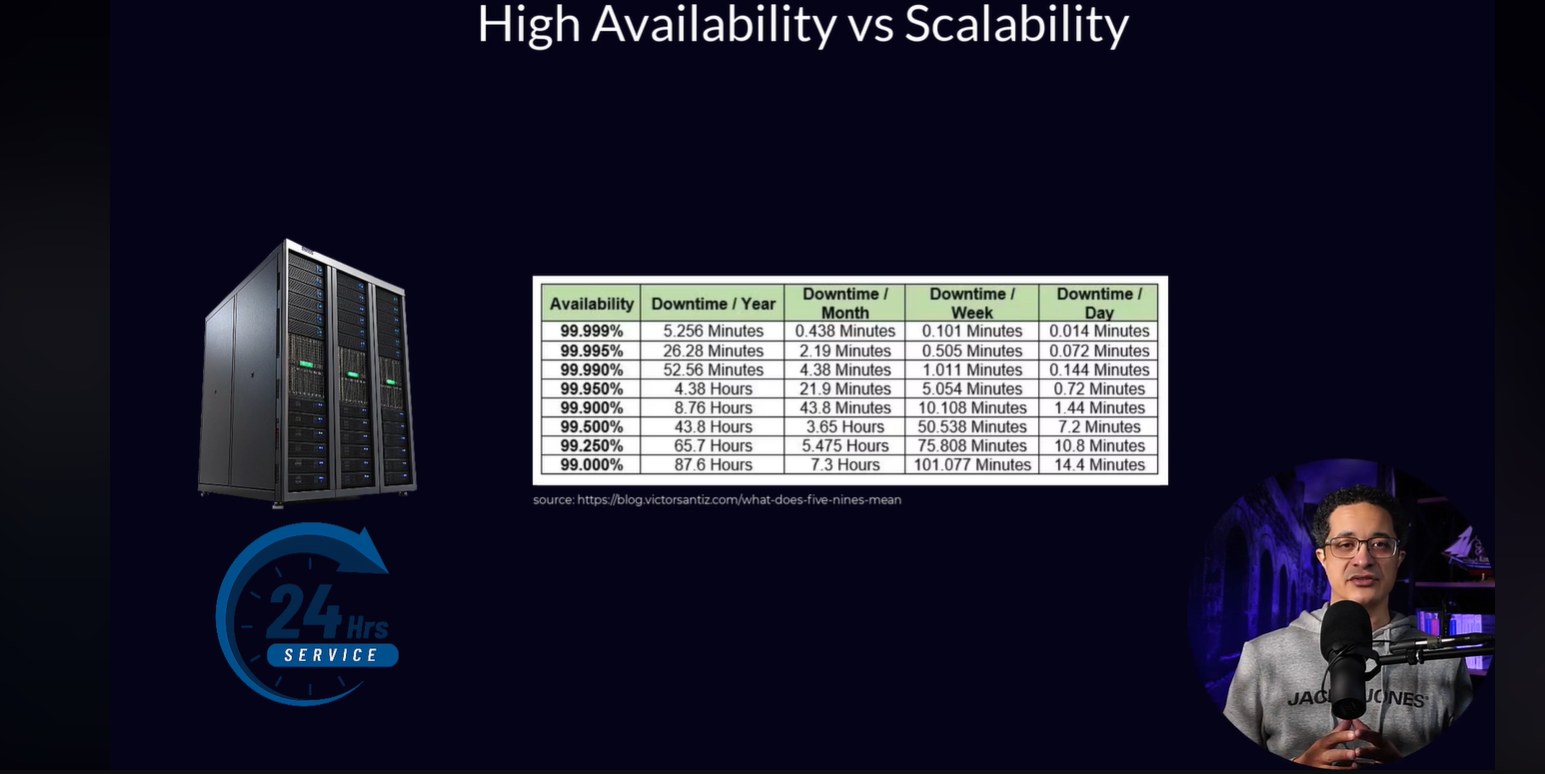


The basic architecture is:

```text
Users
  |
  v
Internet
  |
  v
Application Load Balancer
  |
  +---------------------------+
  |                           |
  v                           v
Availability Zone A       Availability Zone B
  |                           |
EC2 Instance                EC2 Instance
  |                           |
  +-----------+---------------+
              |
              v
       Auto Scaling Group
```


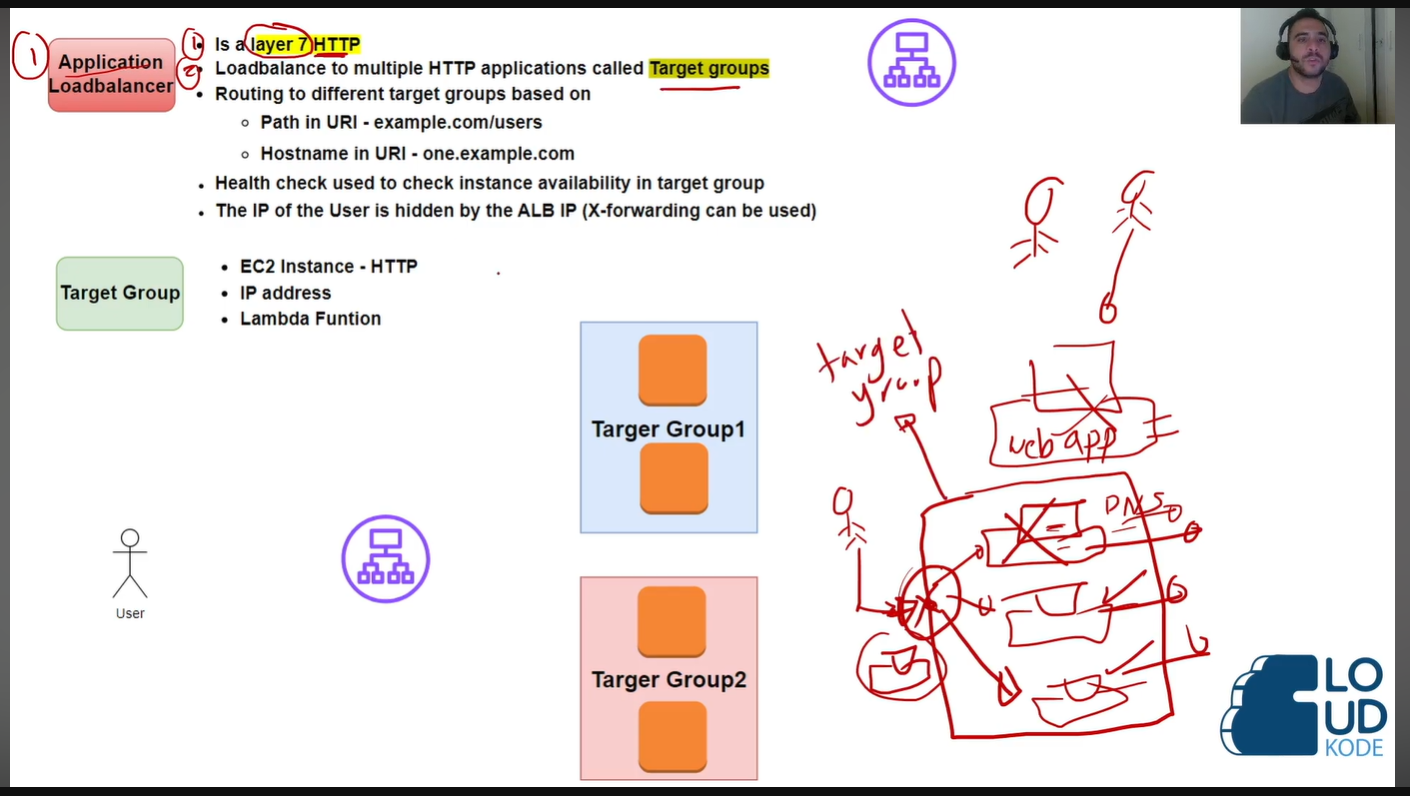

The responsibilities are different:

```text
Load Balancer
     |
     +--> Decides WHERE traffic should go

Auto Scaling Group
     |
     +--> Decides HOW MANY EC2 instances should exist
```

Elastic Load Balancing distributes requests among healthy targets, while Amazon EC2 Auto Scaling maintains the required EC2 capacity and replaces unhealthy instances.

---

## **6.1 Why Do We Need Scaling?**

Imagine an e-commerce application normally receives:

```text
1,000 requests/minute
```

Two EC2 instances may be sufficient.

During a major sale:

```text
20,000 requests/minute
```

The original two instances may reach:

```text
CPU = 95%
Memory = 90%
Response time = very high
```

Eventually:

```text
Requests
   |
   v
EC2 overloaded
   |
   v
Slow application
   |
   v
Timeouts
   |
   v
Application failure
```

One solution would be to permanently deploy 20 EC2 instances.

However, when traffic returns to normal:

```text
20 EC2 instances
       |
       +--> only 2 actually required
       |
       +--> 18 mostly unused
       |
       +--> unnecessary cost
```

Auto Scaling solves this problem by dynamically changing the number of EC2 instances.

```text
Low traffic
    ↓
2 EC2 instances

Medium traffic
    ↓
5 EC2 instances

High traffic
    ↓
10 EC2 instances

Traffic decreases
    ↓
3 EC2 instances
```

---

## **6.2 Vertical Scaling vs Horizontal Scaling**

There are two fundamental methods of scaling infrastructure.

## **6.2.1 Vertical Scaling**

Vertical scaling means increasing the resources of a single server.



Example:

```text
t3.small
   ↓
t3.medium
   ↓
m7i.large
   ↓
m7i.xlarge
```

You increase:

```text
CPU
RAM
Network capacity
```

Architecture:

```text
Before

Application
    |
    v
Small EC2

After

Application
    |
    v
Large EC2
```

### Advantages

* Simple architecture
* Easy for applications that cannot distribute workload
* Useful for some databases

### Disadvantages

* There is a maximum instance size.
* Resizing can require interruption.
* One server can remain a single point of failure.
* Large instance types can become expensive.

---

## **6.2.2 Horizontal Scaling**

Horizontal scaling means adding or removing servers.

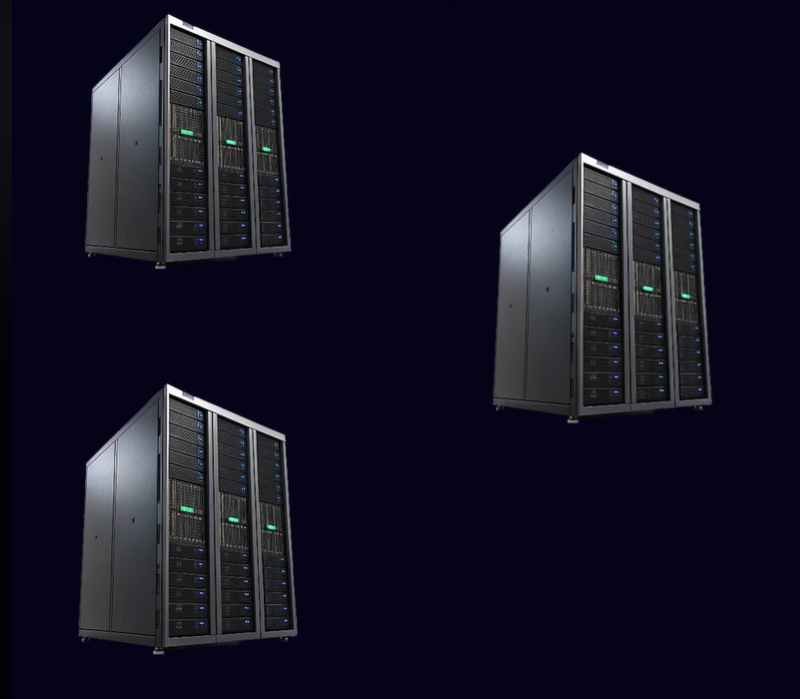


Example:

```text
1 EC2
  ↓
3 EC2
  ↓
6 EC2
  ↓
10 EC2
```

Architecture:

```text
            Load Balancer
                 |
        +--------+--------+
        |        |        |
       EC2      EC2      EC2
```

This is where **Auto Scaling Groups** become important.

AWS cloud-native web architectures generally prefer horizontal scaling when the application can support it.


> We focuse to increase availabilty for our applciation by merging both verticle and horizontal scaling whereas upgrading or downgrading Ec2 will require to shutdown this instance , the solution in Autoscaling Group

---

## **6.3 What Is Amazon EC2 Auto Scaling?**

Amazon EC2 Auto Scaling automatically manages a group of EC2 instances.

The group is called an:

```text
Auto Scaling Group
```

or:

```text
ASG
```

An ASG can:

```text
Launch EC2 instances
        |
        v
Maintain a desired number of instances
        |
        v
Replace unhealthy instances
        |
        v
Add instances when demand increases
        |
        v
Remove instances when demand decreases
```

Amazon EC2 Auto Scaling continuously monitors its instances and can replace an unhealthy `InService` instance to restore the desired capacity.


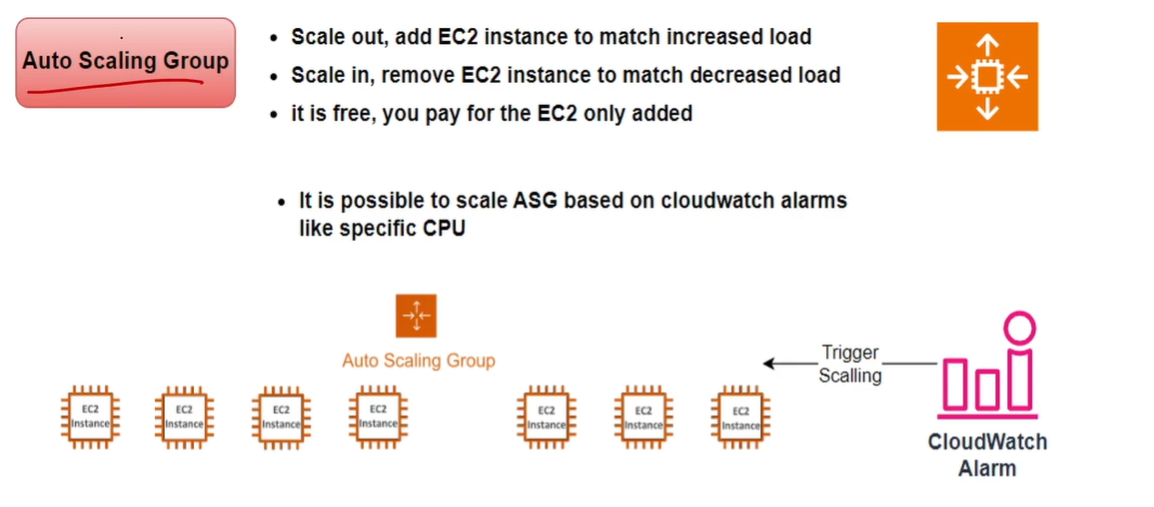

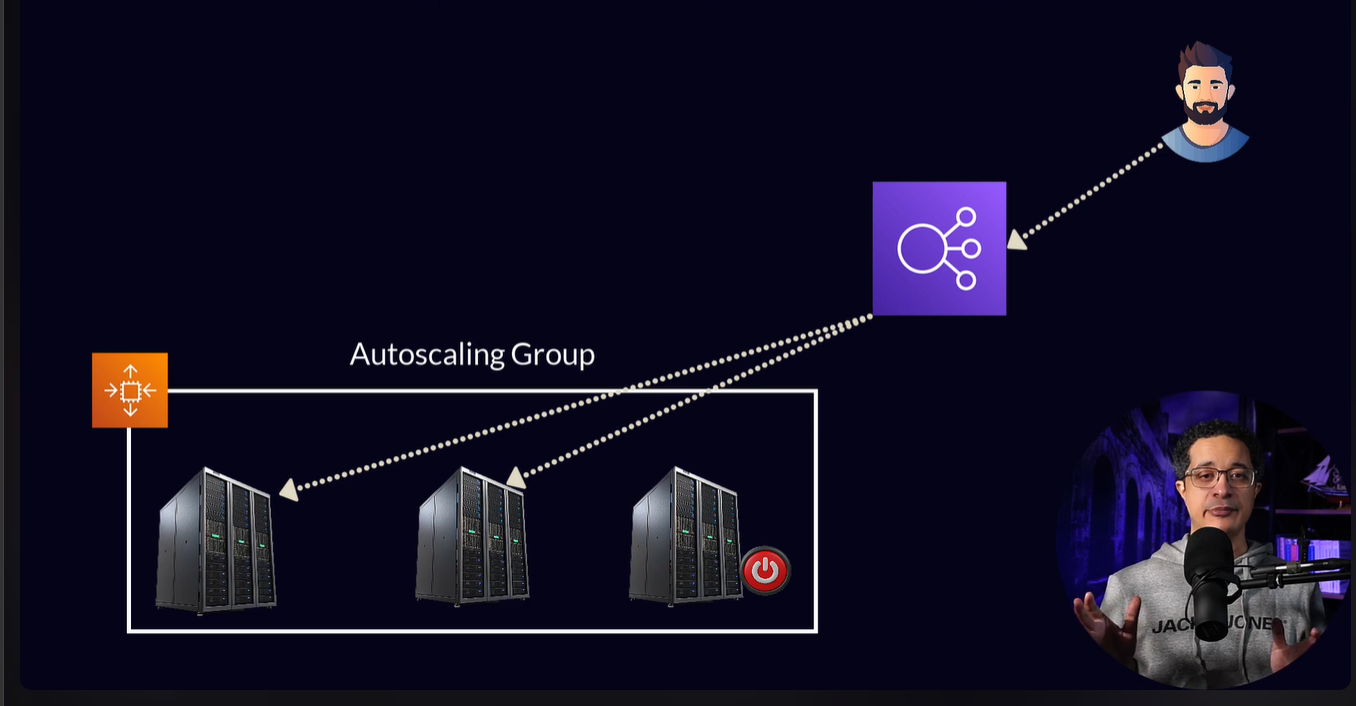



---

## **6.4 Main Components of an Auto Scaling Architecture**

A typical architecture contains:

```text
Launch Template
      |
      v
Auto Scaling Group
      |
      +--> Minimum Capacity
      +--> Desired Capacity
      +--> Maximum Capacity
      |
      +--> Availability Zones
      |
      +--> Scaling Policies
      |
      +--> Health Checks
      |
      v
EC2 Instances
```

The most important concepts are:

1. Launch Template
2. Minimum capacity
3. Desired capacity
4. Maximum capacity
5. Scaling policies
6. Health checks
7. Instance warmup
8. Availability Zones
9. Load balancer target groups

---

## **6.5 Launch Templates**

Before an Auto Scaling Group can create EC2 instances, it needs instructions describing **how those EC2 instances should be created**.

AWS normally uses a:

```text
Launch Template
```

A launch template can define configuration such as:

```text
AMI
Instance type
Security groups
IAM instance profile
Key pair
EBS volumes
User Data
Network configuration
Monitoring settings
Metadata settings
```

For example:

```text
Launch Template
-----------------------------
AMI: Amazon Linux 2023
Instance Type: t3.micro
Security Group: app-sg
IAM Role: WebServerRole
Disk: 20 GB gp3
User Data: install web server
```

Every EC2 instance launched by the ASG can therefore start with the same baseline configuration.

AWS launch templates also support **versioning**, allowing different versions of the configuration to exist.

Example:

```text
Launch Template: web-server-template

Version 1
AMI = ami-old

Version 2
AMI = ami-new

Version 3
AMI = ami-new
Instance Type = t3.medium
```

This becomes particularly useful during deployments.

---

## **6.6 Launch Template vs Launch Configuration**

Historically, AWS supported:

```text
Launch Configurations
```

and:

```text
Launch Templates
```

Launch Templates are the modern mechanism and provide capabilities such as:

* Versioning
* More EC2 options
* Mixed instance configurations
* Better integration with newer EC2 features

Conceptually:

```text
Launch Configuration
        ↓
Older approach

Launch Template
        ↓
Current preferred approach
```

---

## **6.7 Minimum, Desired and Maximum Capacity**

Every Auto Scaling Group has three extremely important values:

```text
Minimum Capacity
Desired Capacity
Maximum Capacity
```

Example:

```text
Min     = 2
Desired = 4
Max     = 10
```

They mean:

| Setting | Meaning                                                 |
| ------- | ------------------------------------------------------- |
| Minimum | ASG should not normally scale below this capacity       |
| Desired | Capacity the ASG currently attempts to maintain         |
| Maximum | Scaling policies cannot normally scale above this limit |

Suppose:

```text
Min     = 2
Desired = 4
Max     = 10
```

Initially:

```text
ASG
 |
 +-- EC2
 +-- EC2
 +-- EC2
 +-- EC2
```

Four instances exist because:

```text
Desired Capacity = 4
```

---

## **6.8 Desired Capacity**

Desired capacity is especially important.

Suppose:

```text
Desired = 4
```

and one instance crashes.

Before:

```text
EC2-1
EC2-2
EC2-3
EC2-4
```

After failure:

```text
EC2-1
EC2-2
EC2-3
EC2-4 X
```

The ASG detects the unhealthy capacity and launches another instance:

```text
EC2-1
EC2-2
EC2-3
EC2-5
```

Therefore:

```text
Actual capacity
        ↓
3

Desired capacity
        ↓
4

Difference
        ↓
1

ASG launches
        ↓
1 new EC2
```

This means Auto Scaling is useful **even when dynamic scaling is not configured**.

An ASG with no scaling policies can simply maintain a fixed desired capacity and replace failed instances.

---

## **6.9 Scale Out and Scale In**

There are two important terms.

## **Scale Out**

Add EC2 instances.

```text
3 EC2
  |
  v
6 EC2
```

Usually happens when demand increases.

Example:

```text
CPU > target
      |
      v
Scale Out
      |
      v
Launch more EC2 instances
```

---

## **6.10 Scale In**

Remove EC2 instances.

```text
6 EC2
  |
  v
3 EC2
```

Usually happens when demand decreases.

Example:

```text
CPU significantly below target
          |
          v
Scale In
          |
          v
Terminate unnecessary instances
```

Together:

```text
Traffic increases
       |
       v
   Scale Out

Traffic decreases
       |
       v
    Scale In
```

---

## **6.11 Scaling Methods**

Amazon EC2 Auto Scaling provides several approaches.

```text
Scaling
   |
   +-- Maintain fixed capacity
   |
   +-- Manual Scaling
   |
   +-- Scheduled Scaling
   |
   +-- Dynamic Scaling
   |      |
   |      +-- Target Tracking
   |      +-- Step Scaling
   |      +-- Simple Scaling
   |
   +-- Predictive Scaling
```

AWS currently supports target tracking, step scaling and simple scaling as dynamic scaling policy types. AWS generally recommends target tracking when an appropriate proportional metric is available.

---

## **6.12 Manual Scaling**

With manual scaling, an administrator changes the desired capacity.

Example:

```text
Before

Min     = 2
Desired = 2
Max     = 10
```

Administrator changes:

```text
Desired = 6
```

ASG launches:

```text
4 additional EC2 instances
```

Result:

```text
Desired = 6
Actual  = 6
```

Manual scaling is useful for:

* Testing
* Maintenance
* Temporary capacity changes
* Troubleshooting

It is not ideal for automatically reacting to production traffic.

---

## **6.13 Scheduled Scaling**

Scheduled scaling changes capacity according to a predefined schedule.

Imagine company traffic is predictable:

```text
08:00 → employees start work
09:00 → high traffic
18:00 → employees leave
```

You could configure:

```text
07:30
Desired Capacity = 10

19:00
Desired Capacity = 2
```

Architecture:

```text
Time
 |
 +-- 07:30 --> Scale to 10
 |
 +-- 19:00 --> Scale to 2
```

Scheduled scaling is useful when workload patterns are known in advance.

Examples:

```text
Business hours
Nightly batch processing
Weekend workloads
Monthly processing
Known marketing events
```

---

## **6.14 Dynamic Scaling**

Dynamic scaling automatically changes capacity based on real-time metrics.

Example:

```text
CloudWatch
    |
    v
CPU Utilization
    |
    +--> High CPU --> Scale Out
    |
    +--> Low CPU  --> Scale In
```

Dynamic scaling can use metrics from Amazon CloudWatch.

Examples:

```text
CPU utilization
Request count
Network metrics
Custom application metric
Queue backlog
ALB request count per target
```

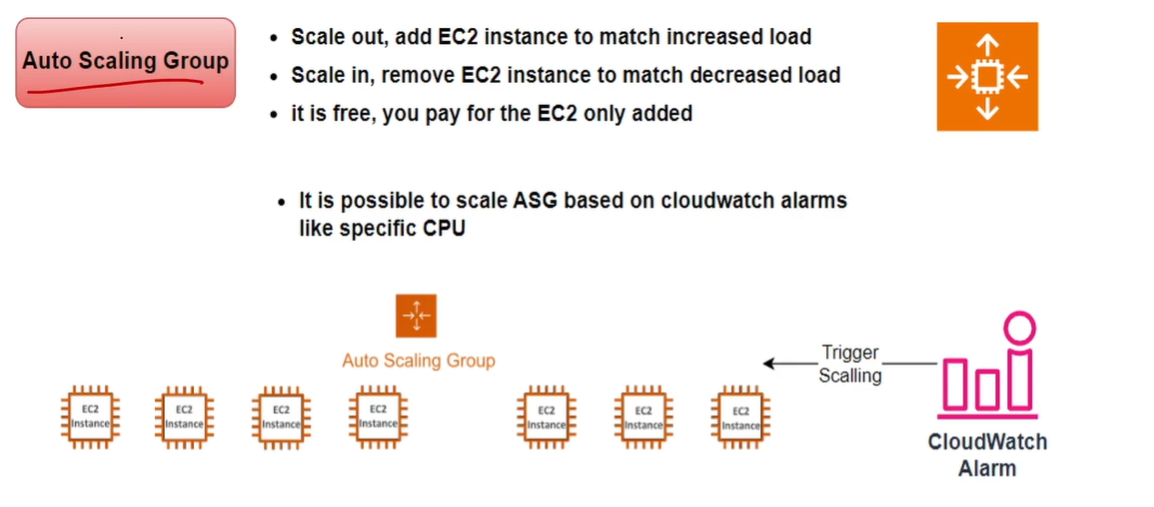


---

## **6.15 Target Tracking Scaling**

Target Tracking is generally the simplest and most useful dynamic scaling method.

You specify a target such as:

```text
Average CPU utilization = 50%
```

Auto Scaling then adjusts capacity to attempt to keep the metric around that target.

Conceptually:

```text
                   Target
                  CPU = 50%
                      |
       +--------------+--------------+
       |                             |
    CPU = 80%                     CPU = 20%
       |                             |
       v                             v
   Scale Out                     Scale In
       |                             |
       +-------------> 50% <---------+
```

AWS compares target tracking to a thermostat: you specify the desired metric value and Auto Scaling manages the CloudWatch alarms and capacity adjustments.

Example:

```text
Target CPU = 50%
```

Current environment:

```text
2 instances
Average CPU = 85%
```

Auto Scaling might increase capacity:

```text
2 → 3 → 4 instances
```

until workload becomes approximately:

```text
Average CPU ≈ 50%
```

---

## **6.16 Good Metrics for Target Tracking**

Good scaling metrics should generally relate workload to available capacity.

For example:

```text
Average CPU Utilization
```

Suppose:

```text
2 instances
CPU = 80%
```

If capacity doubles:

```text
4 instances
```

the same workload might produce approximately:

```text
CPU = 40%
```

This makes CPU useful for many workloads.

Another strong metric when using an ALB is:

```text
ALBRequestCountPerTarget
```

Example:

```text
Target:
1,000 requests / instance
```

Current situation:

```text
3 instances
6,000 requests
```

Average:

```text
2,000 requests/target
```

ASG needs more capacity.

Approximately:

```text
6 instances
6,000 requests

≈ 1,000 requests/target
```

AWS specifically identifies average CPU utilization and average request count per target as examples of metrics suitable for target tracking.

---

## **6.17 Step Scaling**

Step Scaling allows different scaling actions depending on how severely a threshold is exceeded.

Example:

```text
CPU 50-60%
    |
    +1 EC2

CPU 60-75%
    |
    +2 EC2

CPU >75%
    |
    +4 EC2
```

Example policy:

| CPU    |    Action |
| ------ | --------: |
| < 30%  |  Remove 2 |
| 30-50% | No action |
| 50-65% |     Add 1 |
| 65-80% |     Add 2 |
| > 80%  |     Add 4 |

Step scaling is useful when you want more explicit control over scaling behavior.

For example:

```text
CPU = 55%
```

might require only:

```text
+1 instance
```

while:

```text
CPU = 95%
```

might indicate a severe spike requiring:

```text
+5 instances
```

AWS defines step scaling as scaling capacity using adjustments whose magnitude depends on the size of the CloudWatch alarm breach.

---

## **6.18 Simple Scaling**

Simple scaling uses:

```text
CloudWatch Alarm
       #|
       v
One scaling adjustment
       |
       v
Cooldown
```

Example:

```text
CPU > 70%
    |
    v
Add 2 instances
    |
    v
Wait for cooldown
```

It is simpler but generally less flexible than target tracking or step scaling.

For most modern architectures, target tracking is usually a better starting point.

---

## **6.19 Predictive Scaling**

Dynamic scaling is primarily reactive:

```text
Traffic increases
        |
        v
Metric increases
        |
        v
Auto Scaling reacts
        |
        v
Instances launch
```

Predictive Scaling attempts to anticipate future capacity.

```text
Historical metrics
       |
       v
Pattern analysis
       |
       v
Forecast
       |
       v
Scale before traffic arrives
```

Example historical pattern:

```text
Monday-Friday

08:00    Low
09:00    Increasing
10:00    Very high
12:00    Medium
14:00    High
18:00    Low
```

AWS can identify recurring patterns and forecast future capacity requirements. Predictive scaling analyzes historical load data to identify daily or weekly patterns and can proactively add capacity before expected demand.

Predictive scaling is especially useful for:

```text
Regular business-hour traffic
Recurring batch workloads
Predictable weekly traffic
Applications with long startup times
```

AWS currently requires historical metric data before generating predictions; predictive scaling initially supports a forecast-only mode so predictions can be evaluated before allowing them to change capacity.

A strong architecture may combine:

```text
Predictive Scaling
        +
Target Tracking
```

For example:

```text
Predictive Scaling
      |
      +--> prepares for expected traffic

Target Tracking
      |
      +--> reacts to unexpected traffic
```

---

## **6.20 Scaling Limits**

Suppose:

```text
Min     = 2
Desired = 4
Max     = 10
```

A scaling policy calculates that the application needs:

```text
14 instances
```

The ASG normally stops at:

```text
Max = 10
```

Therefore:

```text
Calculated Capacity = 14
Maximum Capacity    = 10

Actual Capacity     = 10
```

This is why setting the maximum capacity correctly is important.

Too low:

```text
Traffic spike
    |
    v
ASG reaches Max
    |
    v
Cannot add enough capacity
    |
    v
Performance degradation
```

Too high without proper controls:

```text
Bad metric / extreme workload
         |
         v
Large scale-out
         |
         v
Unexpected EC2 cost
```

---

## **6.21 Instance Warmup**

A newly launched EC2 instance does not necessarily become productive immediately.

It may need to:

```text
Boot operating system
      |
      v
Run User Data
      |
      v
Install/start services
      |
      v
Load application
      |
      v
Connect to database
      |
      v
Warm caches
      |
      v
Begin handling requests
```

Suppose:

```text
EC2 launch time = 30 seconds
Application initialization = 120 seconds
```

The machine may require:

```text
150 seconds
```

before it should influence scaling calculations normally.

This is one reason the **default instance warmup** setting matters.

Without appropriate warmup behavior:

```text
Traffic high
   |
   v
ASG launches instance
   |
   v
New instance not ready
   |
   v
Metrics still high
   |
   v
ASG launches more instances
```

Potential result:

```text
Overscaling
```

---

## **6.22 Health Check Grace Period**

Health check grace period is a related but different concept.

Suppose your application requires:

```text
2 minutes
```

to become healthy after EC2 starts.

The load balancer may initially report:

```text
Unhealthy
```

If Auto Scaling immediately treats this as a real failure:

```text
Launch instance
      |
      v
Application initializing
      |
      v
Health check fails
      |
      v
ASG terminates instance
      |
      v
Launch another instance
```

This could create a loop.

The health check grace period gives a newly launched instance time to initialize before Auto Scaling reacts to certain health-check failures. AWS documents the grace period specifically as protection against terminating newly initialized instances prematurely.

---

## **6.23 Warmup vs Health Check Grace Period**

These should not be confused.

```text
Instance Warmup
      |
      +--> Primarily affects scaling behavior

Health Check Grace Period
      |
      +--> Primarily affects health-based replacement behavior
```

Simplified:

| Feature                   | Primary Question                                                                       |
| ------------------------- | -------------------------------------------------------------------------------------- |
| Warmup                    | When should this new capacity be considered established for scaling?                   |
| Health-check grace period | How long should Auto Scaling avoid reacting to initialization-related health failures? |

---

## **6.24 Auto Scaling Health Checks**

Amazon EC2 Auto Scaling can receive health information from multiple sources, including:

* EC2 status checks
* Elastic Load Balancing
* VPC Lattice
* Amazon EBS
* Custom health checks

A critical distinction is:

```text
EC2 Health
```

does not necessarily mean:

```text
Application Health
```

For example:

```text
EC2 operating system running
        |
        v
EC2 = Healthy

But

Apache crashed
        |
        v
Website = Unavailable
```

From the infrastructure perspective:

```text
EC2 healthy
```

From the application perspective:

```text
Application unhealthy
```

This is one reason load balancer health checks are extremely useful.

---

## **6.25 Elastic Load Balancing Health Checks and ASG**

Suppose an Application Load Balancer checks:

```text
GET /health
```

Expected response:

```text
HTTP 200
```

Instance A:

```text
/health → 200 OK
```

Result:

```text
Healthy
```

Instance B:

```text
/health → 500
```

Result:

```text
Unhealthy
```

The load balancer stops routing normal requests to the unhealthy target.

If Elastic Load Balancing health checks are enabled for the Auto Scaling Group, Auto Scaling can also replace the unhealthy EC2 instance. By default, EC2 Auto Scaling does not automatically use ELB health-check failures for replacement until ELB health checks are configured for the group.

Thus:

```text
Application fails
       |
       v
ALB health check fails
       |
       v
Target becomes unhealthy
       |
       +--> ALB stops normal routing to it
       |
       v
ASG detects unhealthy target
       |
       v
Terminates/replaces instance
       |
       v
New healthy instance
```

This is a powerful self-healing architecture.

---

## **6.26 What Is Elastic Load Balancing?**

Elastic Load Balancing distributes incoming traffic across multiple targets.

Targets can include resources such as:

```text
EC2 instances
IP addresses
Containers
Lambda functions for supported ALB architectures
Network appliances for GWLB architectures
```

Basic architecture:

```text
                    Users
                      |
                      v
               Load Balancer
                      |
          +-----------+-----------+
          |           |           |
          v           v           v
        EC2-1       EC2-2       EC2-3
```

Instead of users accessing:

```text
EC2-1 directly
```

they access:

```text
Load Balancer
```

The load balancer chooses an appropriate healthy target.

---

## **6.27 Why Use a Load Balancer?**

Without a load balancer:

```text
Client
  |
  v
EC2-1
```

If EC2-1 fails:

```text
Client
  |
  X
EC2-1
```

Application becomes unavailable.

With a load balancer:

```text
             ALB
              |
       +------+------+
       |             |
      EC2           EC2
```

If one fails:

```text
             ALB
              |
       +------+------+
       |             |
    EC2 X           EC2
                      ^
                      |
                Traffic continues
```

A load balancer therefore contributes to:

* High availability
* Fault tolerance
* Traffic distribution
* Health-based routing
* Multi-AZ architectures
* TLS termination
* Application routing

---

## **6.28 AWS Elastic Load Balancer Types**

Elastic Load Balancing supports multiple load-balancer families.

```text
Elastic Load Balancing
         |
         +-- Application Load Balancer
         |
         +-- Network Load Balancer
         |
         +-- Gateway Load Balancer
         |
         +-- Classic Load Balancer
```

The main current choices are:

| Load Balancer | Main Use                                   |
| ------------- | ------------------------------------------ |
| ALB           | HTTP/HTTPS application traffic             |
| NLB           | High-performance network transport traffic |
| GWLB          | Network/security virtual appliances        |
| CLB           | Previous-generation workloads              |

AWS explicitly identifies Classic Load Balancer as the previous generation and recommends migrating to current-generation load balancers.

---

## **6.29 Application Load Balancer — ALB**

Application Load Balancer is designed primarily for application-layer traffic.

Conceptually:

```text
OSI Layer 7
Application Layer
```

It understands application-level request information.

For example:

```text
https://example.com/products
https://example.com/api
https://admin.example.com
```

Because it understands HTTP/HTTPS requests, it can perform advanced routing.

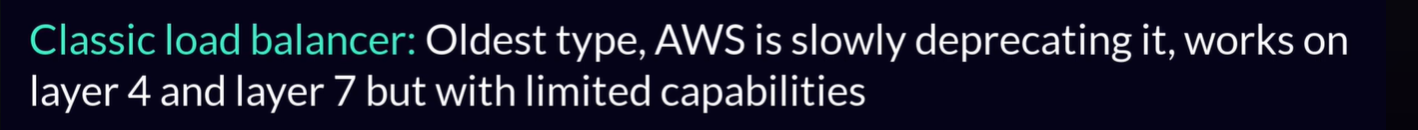

---

## **6.30 ALB Routing**

An ALB can route traffic using listener rules.


Example:

```text
example.com/
      |
      v
Frontend Target Group

example.com/api/*
      |
      v
API Target Group

admin.example.com/*
      |
      v
Admin Target Group
```

Architecture:

```text
                     ALB
                      |
          +-----------+-----------+
          |                       |
      /api/*                   /images/*
          |                       |
          v                       v
     API Servers              Image Servers
```

This is called:

```text
Content-based routing
```

ALB listener rules are evaluated according to their configured priority and can forward different requests to different target groups.

---

## **6.31 Host-Based Routing**

Suppose:

```text
api.example.com
shop.example.com
admin.example.com
```

An ALB can route them separately.

```text
                         ALB
                          |
        +-----------------+-----------------+
        |                 |                 |
 api.example.com   shop.example.com   admin.example.com
        |                 |                 |
        v                 v                 v
      API TG           Shop TG          Admin TG
```

This is extremely useful for:

```text
Microservices
Multi-service applications
Containerized applications
Different backend services
```

---

## **6.32 Path-Based Routing**

Example:

```text
example.com/users/*
        |
        v
User Service

example.com/orders/*
        |
        v
Order Service

example.com/payments/*
        |
        v
Payment Service
```

Architecture:

```text
                        ALB
                         |
        +----------------+----------------+
        |                |                |
     /users/*         /orders/*       /payments/*
        |                |                |
        v                v                v
    User TG          Order TG         Payment TG
```

---

## **6.33 Network Load Balancer — NLB**

Network Load Balancer operates primarily at:


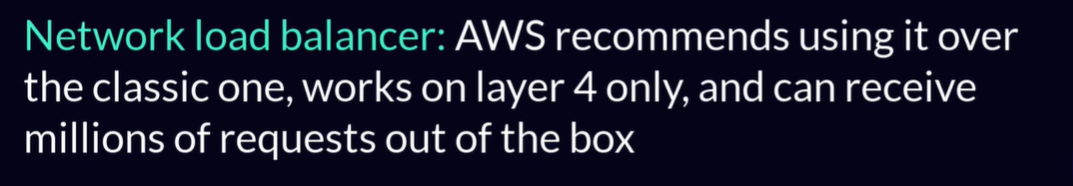


```text
OSI Layer 4
Transport Layer
```

It is designed for very high-performance connection-oriented/network workloads.

Conceptually:

```text
Client
  |
 TCP / TLS / UDP-class traffic
  |
  v
 NLB
  |
  +---------+---------+
  |         |         |
Target 1  Target 2  Target 3
```


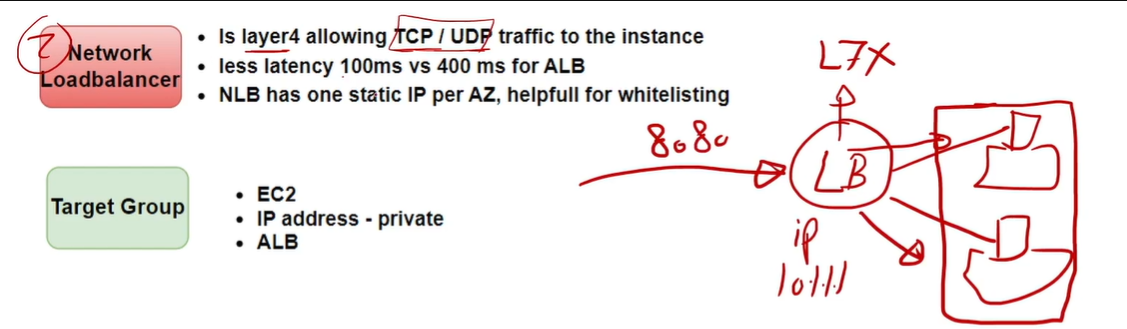

AWS documents NLB as a Layer 4 load balancer designed to handle very large traffic volumes.

Typical NLB use cases include:

```text
Very high connection throughput
Low-latency networking
TCP services
TLS services
UDP-based services
Applications needing network-level load balancing
```

---

## **6.34 ALB vs NLB**

A simplified comparison:

| Feature                              | ALB                 | NLB                                |
| ------------------------------------ | ------------------- | ---------------------------------- |
| Main OSI Layer                       | Layer 7             | Layer 4                            |
| HTTP/HTTPS awareness                 | Yes                 | No application-level HTTP routing  |
| Path routing                         | Yes                 | No                                 |
| Host routing                         | Yes                 | No                                 |
| High network throughput              | High                | Extremely high                     |
| TCP-style workloads                  | Not primary purpose | Yes                                |
| Web applications                     | Excellent           | Possible but usually ALB preferred |
| Microservices HTTP routing           | Excellent           | Limited                            |
| Static network endpoint requirements | Less suited         | Common NLB use case                |

Typical decision:

```text
Web application
      |
      v
ALB
```

while:

```text
High-performance TCP service
      |
      v
NLB
```

---

## **6.35 Gateway Load Balancer — GWLB**

Gateway Load Balancer is designed for deploying and scaling network virtual appliances.

Examples include:

```text
Firewalls
Intrusion detection systems
Intrusion prevention systems
Deep packet inspection appliances
Security appliances
Network monitoring appliances
```

Conceptually:

```text
Application Traffic
        |
        v
      GWLB
        |
        v
Security Appliance Fleet
        |
        v
Destination
```

GWLB is therefore fundamentally different from an ALB.

```text
ALB
 |
 +--> Web/application traffic routing

NLB
 |
 +--> High-performance transport-level traffic

GWLB
 |
 +--> Transparent network/security appliance distribution
```

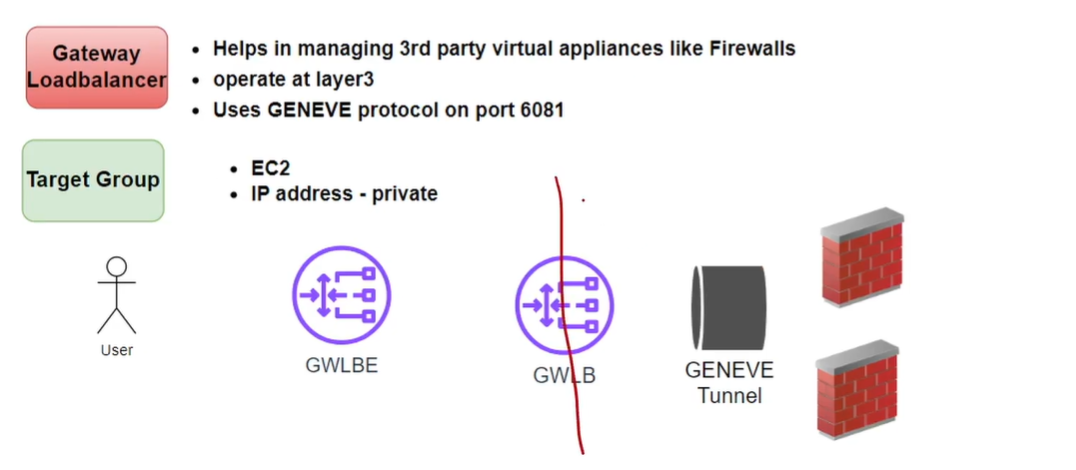

Gateway Load Balancer target groups also support independent health checking of registered network-appliance targets.

---

## **6.36 Classic Load Balancer — CLB**

Classic Load Balancer is the older Elastic Load Balancing generation.


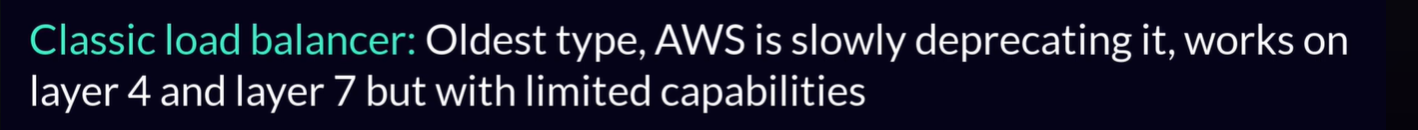

You may still encounter it in:

```text
Old AWS environments
Legacy architectures
Older tutorials
Older certification materials
```

For new architectures, you would normally evaluate:

```text
ALB
NLB
GWLB
```

before considering CLB.

AWS currently describes Classic Load Balancer as the **previous generation** of Elastic Load Balancing.

---

## **6.37 Important Load Balancer Components**

For ALB architectures, understand these four concepts:

```text
Load Balancer
     |
     +--> Listener
     |
     +--> Listener Rules
     |
     +--> Target Groups
     |
     +--> Targets
```

---

## **6.38 Listener**

A listener waits for incoming connections on a specific:

```text
Protocol + Port
```

Examples:

```text
HTTP  : 80
HTTPS : 443
```

Architecture:

```text
User
 |
 v
ALB
 |
 +-- Listener HTTP:80
 |
 +-- Listener HTTPS:443
```

A common production configuration is:

```text
HTTP :80
    |
    v
Redirect to HTTPS

HTTPS :443
    |
    v
Forward to application target group
```

---

## **6.39 Listener Rules**

Listener rules determine what the load balancer does with requests.

Example:

```text
HTTPS :443
    |
    +-- /api/* ------> API Target Group
    |
    +-- /admin/* ----> Admin Target Group
    |
    +-- default -----> Web Target Group
```

Rules can therefore implement sophisticated application-routing architectures.

---

## **6.40 Target Groups**

A Target Group is a logical collection of backend targets.

Example:

```text
Target Group: production-web
Port: 80
Protocol: HTTP

Targets:

10.0.1.10
10.0.2.15
10.0.3.20
```

Architecture:

```text
ALB
 |
 v
Target Group
 |
 +-- EC2-1
 +-- EC2-2
 +-- EC2-3
```

A target group contains important configuration such as:

```text
Protocol
Port
Target type
Health checks
Load-balancing behavior
Stickiness settings
Deregistration behavior
```

AWS performs health checks on targets registered with target groups and routes requests to healthy targets.

---

## **6.41 Target Types**

Depending on the load-balancer architecture, target groups can register targets using different target types.

Common examples include:

```text
Instance
IP address
Lambda — supported ALB use cases
ALB — supported NLB architectures
```

With an EC2 Auto Scaling Group, you commonly use:

```text
Target Type = Instance
```

The ASG then automatically manages target registration and deregistration as instances are launched and terminated.

---

## **6.42 Load Balancer Health Checks**

A health check periodically tests whether a target can handle traffic.

For a web server:

```text
Protocol: HTTP
Port: traffic port
Path: /health
```

Example:

```text
ALB
 |
 +---- GET /health ----> EC2-1
 |
 +---- GET /health ----> EC2-2
 |
 +---- GET /health ----> EC2-3
```

Responses:

```text
EC2-1 → 200 → Healthy

EC2-2 → 200 → Healthy

EC2-3 → timeout → Unhealthy
```

Traffic becomes:

```text
               ALB
                |
          +-----+-----+
          |           |
          v           v
        EC2-1       EC2-2

        EC2-3 X
```

Application Load Balancers periodically check registered targets and normally route requests only to healthy targets.

---

## **6.43 Choosing a Good Health Check Endpoint**

Avoid using a health endpoint that performs unnecessarily expensive operations.

A reasonable endpoint might be:

```text
GET /health
```

returning:

```json
{
  "status": "healthy"
}
```

You need to decide carefully whether health depends on:

```text
Application process
Database
Cache
External APIs
Other services
```

For example, blindly declaring the application unhealthy because one optional third-party API is temporarily unavailable may cause the ASG to replace perfectly functional instances.

Health checks should represent:

> **Can this instance safely handle the type of traffic the load balancer is about to send to it?**

---

## **6.44 Auto Scaling Group + Target Group Integration**

This is one of the most important AWS architectures.

```text
                    Internet
                        |
                        v
                Application LB
                        |
                        v
                  Target Group
                        |
             +----------+----------+
             |                     |
             v                     v
        EC2 Instance          EC2 Instance
             \                     /
              \                   /
               +-----------------+
                       |
                       v
              Auto Scaling Group
```

When the ASG scales out:

```text
ASG launches new EC2
        |
        v
Instance starts
        |
        v
Registered with target group
        |
        v
Health checks pass
        |
        v
ALB sends traffic
```

When the ASG scales in:

```text
ASG chooses instance
        |
        v
Target deregistered/drained
        |
        v
Connections/requests handled according
to deregistration behavior
        |
        v
Instance terminated
```

---

## **6.45 Complete Request Flow**

Consider this architecture:

```text
User
 |
 v
Route 53
 |
 v
Application Load Balancer
 |
 v
Target Group
 |
 v
Auto Scaling Group
 |
 +-- EC2-A
 |
 +-- EC2-B
 |
 +-- EC2-C
```

User requests:

```text
https://shop.example.com/products
```

Request flow:

```text
1. DNS resolves shop.example.com.

2. Request reaches ALB.

3. HTTPS listener receives request.

4. Listener rules evaluate request.

5. Rule selects target group.

6. Load balancer selects a healthy target.

7. Request reaches EC2.

8. EC2 application processes request.

9. Response returns through the load balancer.

10. CloudWatch metrics continue monitoring the system.

11. Scaling policy evaluates load.

12. ASG increases or decreases EC2 capacity when required.
```

---

## **6.46 Multi-AZ Architecture**

A production ASG should generally span multiple Availability Zones.

Example:

```text
Region
 |
 +-------------------------------+
 |                               |
AZ-A                            AZ-B
 |                               |
EC2-1                           EC2-3
EC2-2                           EC2-4
 |                               |
 +---------------+---------------+
                 |
                 v
               ALB
```

If AZ-A experiences a problem:

```text
AZ-A
 X

AZ-B
 |
 +-- EC2-3
 +-- EC2-4
```

traffic can continue through healthy capacity in another Availability Zone.

This protects against more than an individual EC2 instance failure.

---

## **6.47 Recommended Production Network Architecture**

A strong web architecture usually looks like:

```text
                         Internet
                            |
                            v
                    Internet Gateway
                            |
                            v
                Application Load Balancer
                  Public Subnets
                     /       \
                    /         \
                   v           v
              Public AZ-A   Public AZ-B
                    \         /
                     \       /
                      v     v
              ---------------------
              |                   |
          Private AZ-A        Private AZ-B
              |                   |
             EC2                 EC2
              \                   /
               \                 /
                Auto Scaling Group
                       |
                       v
                 Database Layer
```

The important security principle is:

```text
Internet
   |
   v
ALB
   |
   v
Private EC2
```

rather than:

```text
Internet
   |
   v
EC2 directly
```

---

## **6.48 Security Groups**

A common security-group design is:

## ALB Security Group

```text
alb-sg
```

Inbound:

```text
HTTP  80  from 0.0.0.0/0
HTTPS 443 from 0.0.0.0/0
```

or preferably only HTTPS for the application, with HTTP used for redirection where needed.

---

## Application Security Group

```text
app-sg
```

Inbound:

```text
TCP 80
Source = alb-sg
```

Not:

```text
TCP 80
Source = 0.0.0.0/0
```

Result:

```text
Internet
   |
 HTTPS
   |
   v
ALB Security Group
   |
   | HTTP/application port
   |
   v
EC2 Security Group
```

Only the load balancer is allowed to communicate with the application port on the instances.

---

## **6.49 HTTPS and TLS Termination**

An ALB can terminate TLS.

Architecture:

```text
Client
   |
 HTTPS
   |
   v
ALB
   |
   +--> HTTP --> EC2

or

ALB
   |
   +--> HTTPS --> EC2
```

The TLS certificate can be managed using:

```text
AWS Certificate Manager
```

Common architecture:

```text
Client
 |
 | HTTPS :443
 v
ALB + ACM Certificate
 |
 | HTTP or HTTPS
 v
EC2
```

Benefits include:

* Centralized certificate management
* Less certificate-management logic on individual application instances
* Easier scaling
* Easier certificate renewal
* Consistent TLS configuration

---

## **6.50 Sticky Sessions**

Normally:

```text
Request 1 → EC2-A
Request 2 → EC2-B
Request 3 → EC2-C
```

With sticky sessions:

```text
User A
 |
 +--> EC2-B
 +--> EC2-B
 +--> EC2-B
```

Sticky sessions are also called:

```text
Session Affinity
```

They can be useful when an application stores session state locally on an instance.

However, modern scalable application design commonly prefers external session state.

For example:

```text
EC2-A ----\
EC2-B -----+----> ElastiCache / Database
EC2-C ----/
```

Then requests can reach different servers without losing session data.

For ALB, sticky sessions are configured at the target-group level and use cookies.


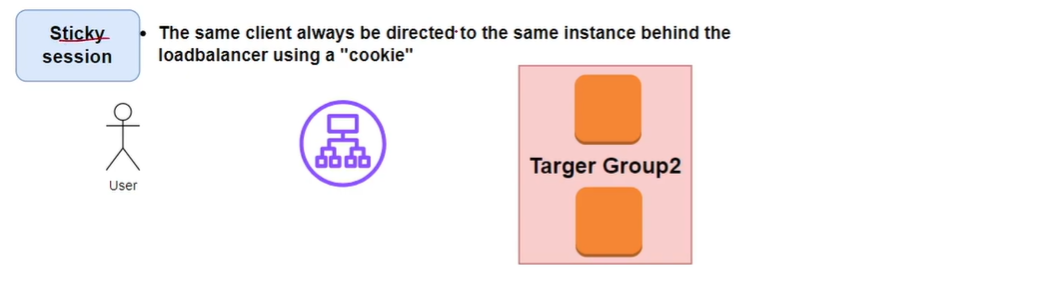


---

## **6.51 Load Balancer SSL Certificate**

An SSL/TLS certificate allows a Load Balancer to provide secure HTTPS communication between users and the application.

```text id="9h3k2c"
User
 |
 | HTTPS :443
 v
Application Load Balancer
 |
 | SSL/TLS Certificate
 v
Secure Connection
```

In AWS, SSL/TLS certificates are commonly created or imported using:

```text id="ym5k2q"
AWS Certificate Manager (ACM)
```

The certificate is attached to the ALB HTTPS listener:

```text id="2x7hsm"
ALB
 |
 +-- HTTP  :80
 |
 +-- HTTPS :443
        |
        +--> ACM Certificate
```

A common configuration redirects HTTP traffic to HTTPS:

```text id="qk3x9p"
HTTP :80
   |
   v
Redirect
   |
   v
HTTPS :443
   |
   v
Target Group
   |
   v
EC2 Instances
```

This provides:

```text id="4mc8ua"
Encrypted communication
Secure user credentials
Certificate management
HTTPS support
```

The Load Balancer can terminate the TLS connection and then forward traffic to the backend using HTTP or HTTPS.

```text id="6fr0sb"
User
 |
 | HTTPS
 v
ALB + SSL Certificate
 |
 | HTTP or HTTPS
 v
EC2
```

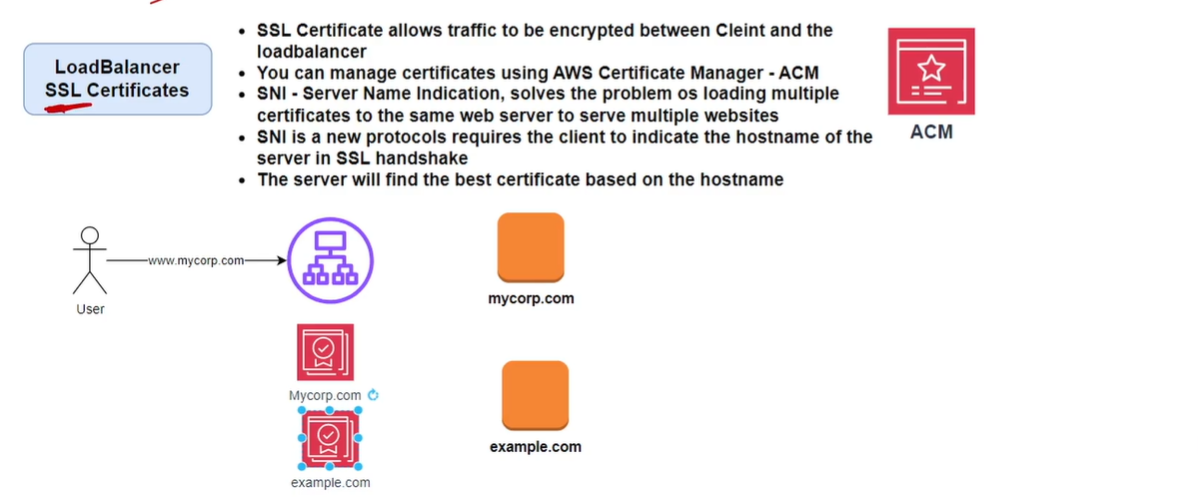


---

## **6.51 Stateless Application Design**

Auto Scaling works best when EC2 instances are replaceable.

Bad architecture:

```text
EC2-A
 |
 +--> User uploaded files
 +--> Session data
 +--> Critical local data
```

If ASG terminates EC2-A:

```text
Data may disappear
```

Better architecture:

```text
                EC2 Instances
                /     |     \
               /      |      \
              v       v       v

Files --------> Amazon S3

Sessions -----> ElastiCache / DynamoDB / DB

Database -----> RDS / Aurora

Logs ---------> CloudWatch / centralized logging
```

Then instances become:

```text
Disposable
Replaceable
Horizontally scalable
Stateless
```

This is one of the most important architectural principles when using Auto Scaling.

---

## **6.52 Deregistration Delay / Connection Draining**

Imagine an EC2 instance is serving:

```text
100 active requests
```

The ASG decides to terminate it.

Immediate termination could result in:

```text
100 failed requests
```

Instead, the target can first enter deregistration behavior.

Conceptually:

```text
Instance selected for termination
        |
        v
Stop sending new requests
        |
        v
Allow in-flight requests time to finish
        |
        v
Deregister target
        |
        v
Terminate instance
```

AWS Auto Scaling can honor load-balancer deregistration delay while in-flight traffic completes before an unhealthy instance is terminated.

---

## **6.53 Slow Start**

A newly started instance may technically be healthy but not yet ready for full traffic.

For example:

```text
Cache cold
JVM warming up
Application initialization
Model loading
```

Instead of immediately receiving:

```text
33% of traffic
```

a new target can gradually receive more traffic.

Conceptually:

```text
0%
 |
10%
 |
25%
 |
50%
 |
75%
 |
100%
```

Application Load Balancer target groups support a `slow_start` period that gradually increases the share of traffic sent to newly registered targets.

This can protect applications with expensive startup behavior.

---

## **6.54 Cross-Zone Load Balancing**

Consider:

```text
AZ-A
3 EC2 instances

AZ-B
1 EC2 instance
```

Without cross-zone distribution at the relevant level, each load-balancer node may favor targets in its local zone depending on the load-balancer type and configuration.

With cross-zone behavior:

```text
Traffic received in a zone
         |
         v
Can be distributed across
healthy targets in multiple zones
```

Current AWS behavior differs by load balancer type and target-group configuration, so it is important to check the relevant configuration rather than assume every load balancer behaves identically. For ALB, cross-zone load balancing is enabled at the load-balancer level, with target-group-level behavior also configurable.

---

## **6.55 Lifecycle Hooks**

Sometimes you need to perform custom operations when an instance:

```text
Launches
```

or:

```text
Terminates
```

Auto Scaling Lifecycle Hooks can pause the lifecycle transition.

Example launch workflow:

```text
ASG launches EC2
       |
       v
Pending
       |
       v
Lifecycle Hook
       |
       +--> Configure software
       +--> Register monitoring agent
       +--> Download configuration
       +--> Notify external system
       |
       v
Complete Lifecycle Action
       |
       v
InService
```

Termination example:

```text
ASG decides to terminate
       |
       v
Lifecycle Hook
       |
       +--> Export logs
       +--> Clean temporary state
       +--> Deregister from external system
       |
       v
Terminate EC2
```

AWS provides lifecycle hooks for instance launch and termination transitions.

---

## **6.56 Warm Pools**

Some applications take a long time to start.

Example:

```text
EC2 boot                 1 min
Application install      3 min
Model loading            4 min
Cache initialization     2 min

Total                    10 min
```

A traffic spike could therefore happen faster than the application can scale.

A **Warm Pool** can maintain initialized instances near the ASG so that capacity can become ready faster than launching completely from scratch.

Conceptually:

```text
                     Auto Scaling Group
                            |
           +----------------+----------------+
           |                                 |
      InService                          Warm Pool
           |                                 |
        EC2 EC2                         EC2 EC2 EC2
```

When additional capacity is required:

```text
Warm Pool
    |
    v
Instance prepared
    |
    v
InService
```

Lifecycle hooks can also be used during warm-pool transitions.

---

## **6.57 Instance Refresh**

Suppose an Auto Scaling Group currently contains four EC2 instances running application version `v1`.

```text
Auto Scaling Group

EC2-1 → AMI v1
EC2-2 → AMI v1
EC2-3 → AMI v1
EC2-4 → AMI v1
```

Later, you create:

```text
AMI v2
```

containing:

```text
New application version
Security patches
Updated dependencies
Updated operating-system packages
New configuration
```

You then create:

```text
Launch Template Version 2
        |
        v
AMI v2
```

Changing the launch template affects **newly launched instances**, but existing instances do not necessarily disappear automatically.

You therefore need a mechanism to replace or update the existing fleet.

That mechanism is:

```text
Instance Refresh
```

### **6.57.1 Basic Instance Refresh Process**

Before:

```text
Launch Template v1
        |
        v
+-------------------+
| Auto Scaling Group|
+-------------------+
   |   |   |   |
   v   v   v   v
  v1  v1  v1  v1
```

Create:

```text
Launch Template v2
```

Then start:

```text
Instance Refresh
```

The replacement happens progressively.

```text
Initial

EC2-1 → v1
EC2-2 → v1
EC2-3 → v1
EC2-4 → v1
```

Then:

```text
EC2-1 → v2
EC2-2 → v1
EC2-3 → v1
EC2-4 → v1
```

Then:

```text
EC2-1 → v2
EC2-2 → v2
EC2-3 → v1
EC2-4 → v1
```

Finally:

```text
EC2-1 → v2
EC2-2 → v2
EC2-3 → v2
EC2-4 → v2
```

---

## **6.58 Why Use Instance Refresh?**

Without Instance Refresh, an administrator might manually update every EC2 instance.

```text
SSH into EC2-1
Update application

SSH into EC2-2
Update application

SSH into EC2-3
Update application
```

This can create:

```text
Configuration drift
Manual errors
Different package versions
Difficult rollback
Slow deployments
```

A better pattern is:

```text
Application Code
      |
      v
Build New AMI
      |
      v
Launch Template v2
      |
      v
Instance Refresh
      |
      v
New Standardized Fleet
```

---

## **6.59 Instance Refresh Availability Control**

During an Instance Refresh, the entire fleet should normally not be terminated at once.

Bad:

```text
10 old instances
      |
      v
Terminate all 10
      |
      v
0 healthy instances
```

Better:

```text
10 old instances
      |
      v
Replace a small batch
      |
      v
8 old + 2 new
      |
      v
Replace next batch
      |
      v
6 old + 4 new
```

This maintains application availability during deployment.

---

## **6.60 Minimum and Maximum Healthy Percentage**

Example:

```text
Desired Capacity = 10

Minimum Healthy Percentage = 80%
```

The refresh should maintain approximately:

```text
At least 8 healthy instances
```

during replacement.

---

## **6.61 Instance Refresh Warmup**

Suppose a new EC2 instance requires:

```text
EC2 startup          = 30 sec
Application startup  = 60 sec
Cache initialization = 60 sec
```

Total:

```text
150 seconds
```

The refresh process should give the instance time to initialize before continuing with further replacement.

```text
Launch EC2
    |
    v
Start application
    |
    v
Pass health check
    |
    v
Warmup
    |
    v
Continue refresh
```

---

## **6.62 Instance Refresh Checkpoints**

For critical deployments:

```text
Refresh 20%
    |
    v
Pause
    |
    v
Validate application
    |
    v
Continue
```

During the checkpoint, monitor:

```text
Application errors
Latency
ALB 5XX errors
Target health
CPU
Memory
Business KPIs
```

---

## **6.63 Skip Matching**

Suppose:

```text
10 instances
```

but:

```text
7 already use Launch Template v2
3 still use Launch Template v1
```

With Skip Matching:

```text
v2 → Skip
v2 → Skip
v1 → Replace
v2 → Skip
v1 → Replace
```

Benefits:

```text
Fewer replacements
Less disruption
Faster refresh
Lower cost
```

---

## **6.64 Instance Refresh Rollback**

Suppose deployment of `v2` causes errors.

```text
Version 1
    |
    v
Instance Refresh
    |
    v
Version 2
    |
    X
Errors
    |
    v
Rollback
    |
    v
Version 1
```

---

## **6.65 Instance Refresh Architecture**

```text
Developer
    |
    v
Git Repository
    |
    v
CI/CD Pipeline
    |
    v
Build Application
    |
    v
Create New AMI
    |
    v
Create Launch Template Version
    |
    v
Start Instance Refresh
    |
    v
Replace Old EC2 Fleet
```

---

## **6.66 Auto Scaling with On-Demand and Spot Instances**

An Auto Scaling Group can combine:

```text
On-Demand Instances
+
Spot Instances
```

Example:

```text
Auto Scaling Group

+------------------+
| On-Demand EC2    |
| On-Demand EC2    |
| Spot EC2         |
| Spot EC2         |
| Spot EC2         |
+------------------+
```

---

## **6.67 Why Combine On-Demand and Spot?**

```text
On-Demand
    |
    +--> Stable baseline
    +--> Predictable availability
    +--> Higher cost
```

```text
Spot
    |
    +--> Lower cost
    +--> Interruptible
```

Common design:

```text
Base Capacity
     |
     v
On-Demand

Extra Elastic Capacity
     |
     v
Spot
```

---

## **6.68 On-Demand Base Capacity**

Example:

```text
OnDemandBaseCapacity = 2
```

If:

```text
Desired Capacity = 8
```

the first two instances can be On-Demand, while the remaining capacity follows the configured distribution policy.

---

## **6.69 Multiple Instance Types**

Instead of using only:

```text
m7i.large
```

you can allow:

```text
m7i.large
m7a.large
m6i.large
m6a.large
```

This improves EC2 capacity flexibility.

---

## **6.70 Spot Allocation Strategy**

A commonly useful strategy is:

```text
price-capacity-optimized
```

Conceptually:

```text
Available Spot Pools
        |
        v
Evaluate Capacity + Price
        |
        v
Choose Suitable Capacity
```

---

## **6.71 Capacity Rebalancing**

```text
Spot Instance
      |
      v
Rebalance Recommendation
      |
      v
Launch Replacement
      |
      v
Replacement Ready
      |
      v
Old Spot Interrupted
```

---

## **6.72 Good Workloads for Spot + Auto Scaling**

Good candidates:

```text
Web servers
REST APIs
Batch workers
CI/CD runners
Data processing
Rendering
Analytics workloads
Container workers
```

They should ideally be:

```text
Stateless
Replaceable
Fault tolerant
Horizontally scalable
```

---

## **6.73 Instance Scale-In Protection**

Example:

```text
EC2-A → Protected
EC2-B → Eligible
EC2-C → Eligible
```

If the ASG needs to scale from three instances to two:

```text
3 → 2
```

it avoids selecting the protected instance during normal scale-in.

---

## **6.74 Scale-In Protection vs EC2 Termination Protection**

```text
Scale-In Protection
=
Protects from normal ASG scale-in
```

```text
EC2 Termination Protection
=
Protects against certain direct EC2 termination operations
```

They are not the same feature.

---

## **6.75 CloudWatch and Auto Scaling**

```text
Application / EC2 / ALB
          |
          v
        Metrics
          |
          v
      CloudWatch
          |
          v
    Scaling Policy
          |
          v
         ASG
       /     \
      v       v
 Scale Out  Scale In
```

---

## **6.76 Important Auto Scaling Group Metrics**

Examples:

```text
GroupMinSize
GroupMaxSize
GroupDesiredCapacity
GroupInServiceInstances
GroupPendingInstances
GroupTerminatingInstances
GroupTotalInstances
```

Example:

```text
GroupDesiredCapacity = 6
GroupInServiceInstances = 4
GroupPendingInstances = 2
```

---

## **6.77 Important EC2 Metrics**

Examples:

```text
CPUUtilization
NetworkIn
NetworkOut
DiskReadOps
DiskWriteOps
StatusCheckFailed
```

For memory and filesystem utilization, the CloudWatch Agent is commonly required.

---

## **6.78 Important ALB Metrics**

Examples:

```text
RequestCount
RequestCountPerTarget
TargetResponseTime
HealthyHostCount
UnHealthyHostCount
HTTPCode_ELB_5XX_Count
HTTPCode_Target_5XX_Count
```

---

## **6.79 ELB 5XX vs Target 5XX**

```text
HTTPCode_ELB_5XX_Count
```

means the load-balancer layer generated the error.

```text
HTTPCode_Target_5XX_Count
```

means the backend application returned the error.

---

## **6.80 Scaling Based on CPU**

Example:

```text
Min     = 2
Desired = 2
Max     = 10

Target CPU = 50%
```

Current CPU:

```text
EC2-1 = 90%
EC2-2 = 80%
```

Average:

```text
85%
```

Since:

```text
85% > 50%
```

the ASG can scale out.

---

## **6.81 Scaling Based on ALB Request Count**

Example target:

```text
1,000 requests / target
```

Current:

```text
6,000 requests
3 targets
```

Therefore:

```text
2,000 requests / target
```

Scaling toward six instances gives approximately:

```text
6,000 / 6
=
1,000 requests / target
```

---

## **6.82 Scaling Based on SQS Queue Depth**

```text
Producer
   |
   v
Amazon SQS
   |
   v
Worker ASG
```

Possible scaling signal:

```text
Messages waiting
/
Number of workers
```

As backlog increases:

```text
Queue increases
      |
      v
Scale Out
      |
      v
More workers
```

---

## **6.83 Scaling Based on Memory**

Example:

```text
CPU    = 25%
Memory = 95%
```

CPU-based scaling may miss the real bottleneck.

Use:

```text
CloudWatch Agent
      |
      v
Memory Metric
      |
      v
Scaling Policy
```

---

## **6.84 Scaling Based on Business Metrics**

Examples:

```text
Active users
Orders per minute
Pending jobs
Concurrent sessions
AI inference requests
Images waiting for processing
```

Architecture:

```text
Application
    |
    v
Custom CloudWatch Metric
    |
    v
Scaling Policy
    |
    v
ASG
```

---

## **6.85 Practical E-Commerce Scenario**

```text
Route 53
   |
   v
ALB
   |
   v
Target Group
   |
   v
ASG
 |
 +-- EC2-A
 +-- EC2-B
```

Configuration:

```text
Min     = 2
Desired = 2
Max     = 20

Target CPU = 50%
```

At peak traffic:

```text
2
↓
4
↓
6
↓
10
↓
14
```

At night:

```text
14
↓
8
↓
4
↓
2
```

---

## **6.86 Auto Scaling Failure Recovery**

Suppose:

```text
Desired Capacity = 4
```

Current fleet:

```text
EC2-A
EC2-B
EC2-C
EC2-D
```

EC2-C fails.

```text
Healthy Capacity = 3
Desired Capacity = 4
```

ASG launches:

```text
EC2-E
```

Final:

```text
EC2-A
EC2-B
EC2-D
EC2-E
```

This is a form of:

```text
Self-Healing Infrastructure
```

---

## **6.87 ALB + ASG Failure Recovery**

```text
EC2 running
    |
    v
Application crashes
    |
    v
ALB Health Check Fails
    |
    v
Target Unhealthy
    |
    v
ALB Stops Routing Traffic
    |
    v
ASG Replaces Instance
```

---

## **6.88 Availability Zone Failure**

```text
Region

AZ-A
 |
 +-- EC2-A
 +-- EC2-B

AZ-B
 |
 +-- EC2-C
 +-- EC2-D
```

If AZ-A fails:

```text
AZ-A X

AZ-B
 |
 +-- EC2-C
 +-- EC2-D
```

healthy capacity can continue serving traffic.

---

## **6.89 Multi-Tier Auto Scaling Architecture**

```text
                       ALB
                        |
        +---------------+---------------+
        |                               |
     /api/*                          /admin/*
        |                               |
        v                               v
     API TG                         Admin TG
        |                               |
        v                               v
     API ASG                         Admin ASG
```

Each ASG can scale independently.

---

## **6.90 Stateless Application Principle**

Bad:

```text
EC2

+ Sessions
+ Uploaded files
+ Important local state
```

Better:

```text
Sessions  → ElastiCache
Files     → S3
Database  → RDS / Aurora
Shared FS → EFS
Logs      → CloudWatch
```

Then EC2 instances become disposable and replaceable.

---

## **6.91 Auto Scaling with RDS**

```text
Users
  |
  v
ALB
  |
  v
ASG
 |
 +-- EC2
 +-- EC2
 +-- EC2
       |
       v
      RDS
```

The EC2 tier and database tier scale independently.

---

## **6.92 Auto Scaling with S3**

Avoid storing uploads only on EC2.

Better:

```text
EC2-A -----\
EC2-B ------+----> S3
EC2-C -----/
```

---

## **6.93 Auto Scaling with ElastiCache**

```text
EC2-A -----\
EC2-B ------+----> ElastiCache
EC2-C -----/
```

This can centralize:

```text
Sessions
Cache data
Temporary shared state
```

---

## **6.94 Production Architecture**

```text
                         Internet
                            |
                            v
                        Route 53
                            |
                            v
                       CloudFront
                            |
                            v
                 Application Load Balancer
                            |
                +-----------+-----------+
                |                       |
             AZ-A                     AZ-B
                |                       |
          Private EC2              Private EC2
                \                       /
                 \                     /
                  Auto Scaling Group
                          |
        +-----------------+-----------------+
        |                 |                 |
        v                 v                 v
    RDS/Aurora        ElastiCache           S3
```

---

## **6.95 Auto Scaling and CI/CD**

```text
Developer
    |
    v
GitHub
    |
    v
GitHub Actions
    |
    v
Tests
    |
    v
Build Application
    |
    v
Create AMI
    |
    v
Launch Template Version
    |
    v
Instance Refresh
    |
    v
New EC2 Fleet
```

---

## **6.96 Auto Scaling with Terraform**

Conceptually:

```hcl
resource "aws_launch_template" "web" {
  # EC2 configuration
}

resource "aws_autoscaling_group" "web" {
  min_size         = 2
  desired_capacity = 2
  max_size         = 10
}

resource "aws_lb" "web" {
  # Application Load Balancer
}

resource "aws_lb_target_group" "web" {
  # Target Group
}
```

---

## **6.97 Troubleshooting Auto Scaling**

If an ASG cannot launch instances, inspect:

```text
Auto Scaling Group
      |
      v
Activity History
```

Possible causes:

```text
Invalid launch template
Invalid AMI
IAM permissions
EC2 quota
Subnet IP exhaustion
Unsupported instance type
Insufficient EC2 capacity
```

---

## **6.98 Troubleshooting Unhealthy Targets**

Check:

```text
Application running?
Correct port?
Correct health-check path?
Correct security groups?
Correct protocol?
Correct success code?
User Data completed?
Application bound to correct interface?
```

---

## **6.99 Troubleshooting Scaling That Does Not Occur**

Suppose:

```text
CPU = 90%
```

but:

```text
Desired Capacity = 2
```

Check:

```text
Scaling policy
CloudWatch metric
Maximum capacity
Warmup
Suspended processes
Scaling activity
Alarm state
```

For example:

```text
Min     = 2
Desired = 2
Max     = 2
```

means the group cannot scale above two instances.

---

## **6.100 Troubleshooting Continuous Scaling**

Example:

```text
2
↓
6
↓
3
↓
8
↓
4
```

Possible causes:

```text
Unstable metric
Poor thresholds
Too-short warmup
Traffic oscillation
Large scaling adjustments
Slow application startup
```

---

## **6.101 Auto Scaling Cost Optimization**

Without scaling:

```text
20 EC2 instances
24/7
```

With scaling:

```text
Peak       → 20
Normal     → 8
Night      → 2
```

Additional cost optimization can combine:

```text
Auto Scaling
+
Spot
+
Savings Plans
+
Right-sized instance types
```

---

## **6.102 High Availability vs Auto Scaling**

```text
High Availability
=
Remain operational during failures
```

```text
Auto Scaling
=
Automatically maintain or modify compute capacity
```

Together:

```text
Multi-AZ
+
ALB
+
ASG
```

provide strong availability and elasticity.

---

## **6.103 Elasticity vs Scalability**

```text
Scalability
=
Can the system grow?
```

```text
Elasticity
=
Can the system automatically grow and shrink?
```

---

## **6.104 Fault Tolerance vs High Availability**

```text
High Availability
=
Minimize service interruption
```

```text
Fault Tolerance
=
Continue functioning despite component failure
```

---

## **6.105 Best-Practice Architecture**

```text
Users
  |
  v
Route 53
  |
  v
CloudFront
  |
  v
ALB
  |
  v
Target Group
  |
  v
Multi-AZ ASG
  |
  +-- EC2 AZ-A
  +-- EC2 AZ-B
  +-- EC2 AZ-C
```

Persistent state:

```text
Files      → S3
Database   → RDS/Aurora
Cache      → ElastiCache
Sessions   → ElastiCache/DynamoDB
Logs       → CloudWatch
Secrets    → Secrets Manager
```

---

## **6.106 Recommended Auto Scaling Best Practices**

```text
1. Use multiple Availability Zones.
2. Keep application servers stateless.
3. Store persistent data outside EC2.
4. Use Launch Templates.
5. Use application-level health checks.
6. Configure realistic warmup.
7. Configure health-check grace periods.
8. Prefer target tracking where appropriate.
9. Choose workload-correlated metrics.
10. Set sensible Min and Max capacity.
11. Monitor scaling activities.
12. Monitor healthy/unhealthy hosts.
13. Use private subnets for EC2.
14. Restrict EC2 access to the ALB security group.
15. Use HTTPS and ACM.
16. Use Instance Refresh for deployments.
17. Consider Spot for fault-tolerant workloads.
18. Use multiple instance types for flexibility.
19. Use Capacity Rebalancing with Spot where appropriate.
20. Automate infrastructure using IaC.
```

---

## **6.107 Key Interview Questions**

### **Q1: What does an Auto Scaling Group do?**

It maintains and dynamically adjusts EC2 capacity.

### **Q2: What is Scale Out?**

```text
Add instances
```

### **Q3: What is Scale In?**

```text
Remove instances
```

### **Q4: What is Instance Refresh?**

A rolling mechanism for updating existing ASG instances to a new desired configuration.

### **Q5: Why combine ALB and ASG?**

```text
ALB
=
Distributes requests

ASG
=
Controls capacity
```

### **Q6: Can an ASG work without an ALB?**

Yes.

Example:

```text
SQS
 |
 v
Worker ASG
```

### **Q7: Why should ASG instances be stateless?**

Because they may be terminated and replaced automatically.

---

## **6.108 Final Mental Model**

```text
                           USERS
                             |
                             v
                         Route 53
                             |
                             v
                  Application Load Balancer
                             |
                             v
                       Target Group
                             |
              +--------------+--------------+
              |              |              |
              v              v              v
            EC2            EC2            EC2
              \              |              /
               \             |             /
                +------------+------------+
                             |
                             v
                   Auto Scaling Group
                             |
               +-------------+-------------+
               |             |             |
               v             v             v
             Min         Desired          Max
                             |
                             v
                    Scaling Policies
                             |
                             v
                        CloudWatch
```

The essential relationships are:

```text
ALB
=
Where should the request go?

Target Group
=
Which backend targets can receive it?

Health Check
=
Which targets are healthy?

Launch Template
=
How should new EC2 instances be created?

ASG
=
How many EC2 instances should exist?

Scaling Policy
=
When should capacity change?

CloudWatch
=
What is happening?

Instance Refresh
=
How should the running fleet be updated?
```


# **7. VPC Networking**


Amazon VPC is one of the core networking services in AWS.

From this course section, the VPC-related topics are:

```text
8. VPC Networking
9. VPC Lab
10. Direct Connect vs VPN
```

This chapter covers:

- Amazon VPC
- CIDR blocks
- Subnets
- Availability Zones
- Public and private subnets
- Internet Gateway
- Route Tables
- Security Groups
- Network ACLs
- NAT Gateway
- Elastic IP
- VPC Peering
- Transit Gateway
- VPC Endpoints
- VPC Flow Logs
- Site-to-Site VPN
- AWS Direct Connect
- Direct Connect vs VPN
- Practical VPC Lab

---

## 7.1 What Is Amazon VPC?

**Amazon VPC (Virtual Private Cloud)** is a logically isolated virtual network inside the AWS Cloud.


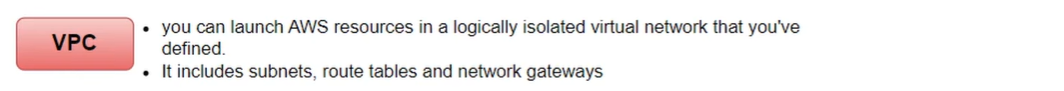


It allows you to create your own network environment where AWS resources can run.

Examples of resources that can exist inside or interact with a VPC include:

```text
EC2
RDS
Application Load Balancer
ECS
EKS
Lambda
NAT Gateway
VPC Endpoints
```

Think of a VPC as your own private network inside AWS.

```text
AWS Cloud
│
└── VPC
    │
    ├── Public Subnet
    │   └── Load Balancer
    │
    ├── Private Subnet
    │   └── EC2
    │
    └── Private Subnet
        └── RDS
```

Inside a VPC, you control:

```text
IP addresses
Subnets
Routing
Internet connectivity
Firewall rules
Private connectivity
Hybrid connectivity
```

---

## 7.2 VPC CIDR Block

When creating a VPC, you define an IP address range.

Example:

```text
10.0.0.0/16
```

This is written using **CIDR notation**.

CIDR means:

```text
Classless Inter-Domain Routing
```

The `/16` determines how large the network is.

For:

```text
10.0.0.0/16
```

the IPv4 address range is approximately:

```text
10.0.0.0
    ↓
10.0.255.255
```

A `/16` contains:

```text
65,536 IPv4 addresses
```

Example:

```text
VPC
10.0.0.0/16
```

We can divide this network into smaller networks called **subnets**.

---

## 7.3 What Is a Subnet?

A **subnet** is a smaller network inside a VPC.

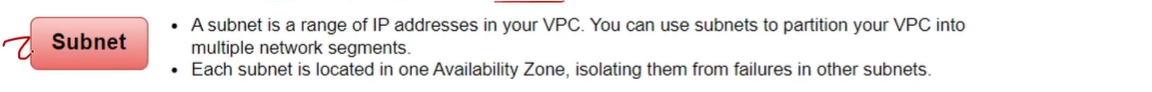
 
Example:

```text
VPC
10.0.0.0/16

├── Public Subnet A
│   10.0.1.0/24
│
├── Public Subnet B
│   10.0.2.0/24
│
├── Private Subnet A
│   10.0.11.0/24
│
└── Private Subnet B
    10.0.12.0/24
```

A `/24` subnet contains:

```text
256 IPv4 addresses
```

Example:

```text
10.0.1.0/24
```

covers approximately:

```text
10.0.1.0
    ↓
10.0.1.255
```

---

## 7.4 Reserved IP Addresses in AWS Subnets

AWS reserves five IPv4 addresses in each subnet.

For example:

```text
10.0.1.0/24
```

AWS reserves addresses for:

```text
Network address
VPC router
DNS server
AWS reserved address
Network broadcast address
```

Therefore, not all 256 addresses are available to your resources.

---

## 7.5 Availability Zones and Subnets

A subnet belongs to exactly **one Availability Zone**.

For example:

```text
VPC
10.0.0.0/16

Availability Zone A
├── Public Subnet A
└── Private Subnet A

Availability Zone B
├── Public Subnet B
└── Private Subnet B
```

A subnet cannot span multiple Availability Zones.

This is important for high availability.

Instead of:

```text
One EC2
One subnet
One AZ
```

a production application may use:

```text
                 Internet
                    |
                   ALB
              /            \
             /              \
       AZ-A                    AZ-B
        |                       |
      EC2-A                   EC2-B
        |                       |
   Private-A               Private-B
          \                 /
               Database
```

If one Availability Zone experiences a failure, another Availability Zone may continue serving the application.

![](https://www.wasilzafar.com/images/series/cloud-computing/aws-vpc-subnet-architecture.webp)

---

## 7.6 Public Subnet

A **public subnet** is a subnet that has a route to an **Internet Gateway**.

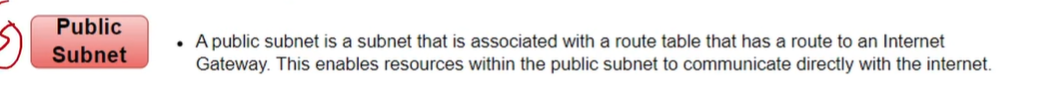

Example route table:

```text
Destination        Target
--------------------------------
10.0.0.0/16        local
0.0.0.0/0          Internet Gateway
```

Architecture:

```text
Internet
   |
Internet Gateway
   |
Public Route Table
   |
Public Subnet
   |
EC2
```

A public subnet alone does not automatically make every resource public.

For an EC2 instance to communicate directly with the internet, it generally needs:

```text
Internet Gateway
      +
Route to Internet Gateway
      +
Public IPv4 address
      +
Correct Security Group rules
```

---

## 7.7 Private Subnet

A **private subnet** does not have a direct route to an Internet Gateway.

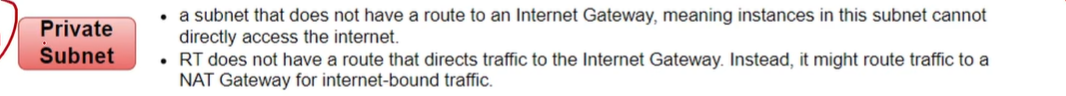

Private subnets are commonly used for:

```text
Application servers
Databases
Backend services
Containers
Internal APIs
Caching systems
```

Example:

```text
Internet
   |
Load Balancer
   |
Public Subnet
   |
Application
   |
Private Subnet
   |
RDS Database
```

The database does not need to be directly exposed to the internet.

This is generally safer than placing sensitive resources in public subnets.

---

## 7.8 Internet Gateway

An **Internet Gateway (IGW)** connects a VPC to the public internet.


![](https://assets-global.website-files.com/6340354625974824cde2e195/6578d079260c3223351bd0d3_6hBOTP_eTKiei4JgB1Ds52pEMmCFRCXP0n66tEh_gQBDNhQ8jtLcSWPPNxpEC3s6YjhsGqBj5bZ1ooFo07T1d16wGGoByH7C-QogSh1Ca2-aXt3QbXLYnrrOf0orVgZ3iwqZPizaUx3cUuAd1v9Uvq8.gif)

Architecture:

```text
Internet
   |
Internet Gateway
   |
VPC
```

Example:

```text
Internet
   |
   v
Internet Gateway
   |
   v
Public Route Table
   |
   v
Public Subnet
   |
   v
EC2
```

An Internet Gateway is attached to the VPC.

Example:

```text
MyVPC
   |
My-Internet-Gateway
```

A route such as:

```text
0.0.0.0/0 → Internet Gateway
```

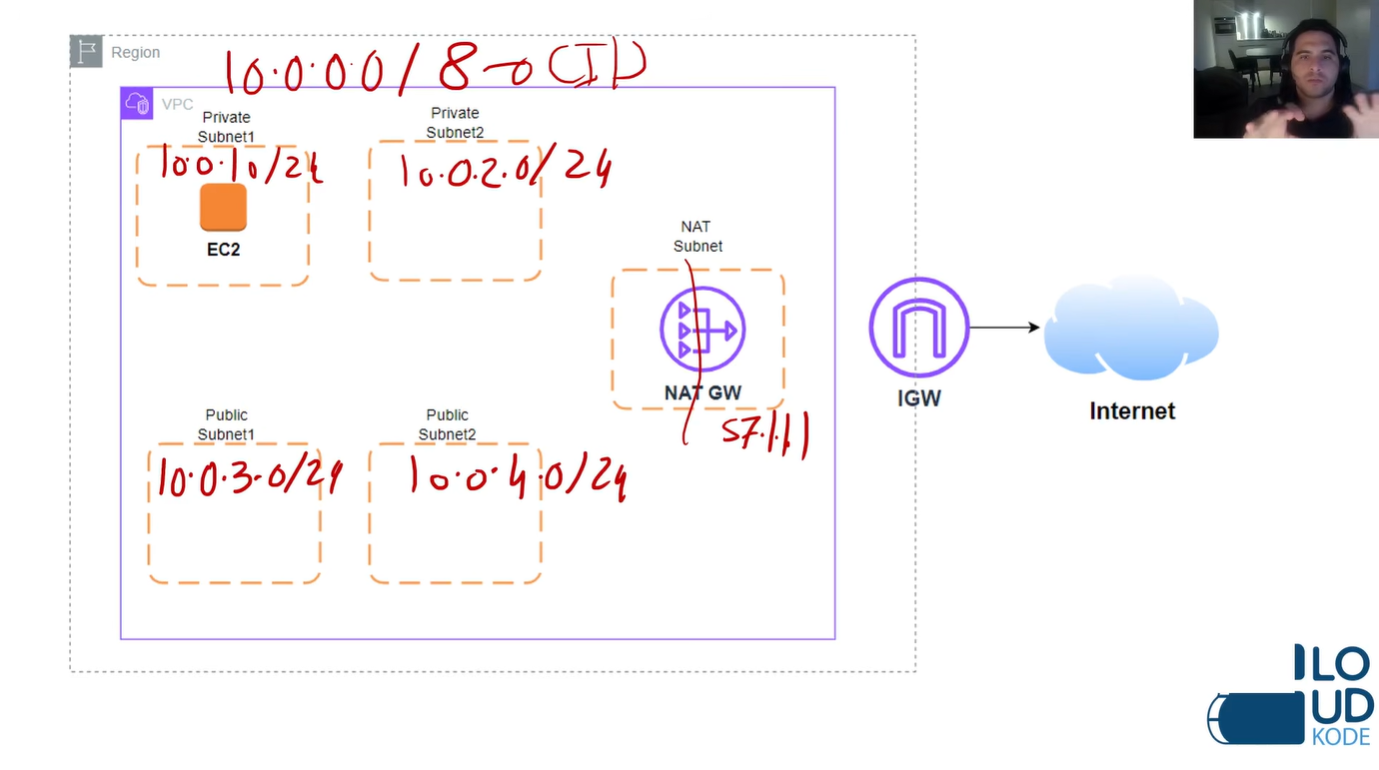

allows traffic destined outside the VPC to be sent toward the internet.

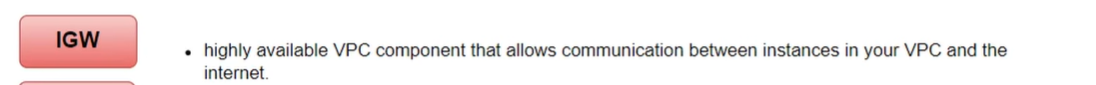



> **Note — Public vs Private Subnet Internet Access**
>
> The main difference is how each subnet reaches the internet.
>
> ### Public Subnet
>
> A public subnet can reach the internet directly through an **Internet Gateway (IGW)**.
>
> ```text
> Public EC2
>     |
>     v
> Internet Gateway (IGW)
>     |
>     v
> Internet
> ```
>
> Typical route:
>
> ```text
> 0.0.0.0/0 → Internet Gateway
> ```
>
> The EC2 instance also normally needs a **Public IP or Elastic IP**.
>
> ### Private Subnet
>
> A private subnet does **not** connect directly to the Internet Gateway.
>
> For outbound internet access, it normally uses a **NAT Gateway**.
>
> ```text
> Private EC2
>     |
>     v
> NAT Gateway
>     |
>     v
> Internet Gateway (IGW)
>     |
>     v
> Internet
> ```
>
> Typical private subnet route:
>
> ```text
> 0.0.0.0/0 → NAT Gateway
> ```
>
> The NAT Gateway itself is placed in a **public subnet** and uses the Internet Gateway to reach the internet.
>
> ### Easy Way to Remember
>
> ```text
> Public Subnet:
>
> EC2 → IGW → Internet
> ```
>
> ```text
> Private Subnet:
>
> EC2 → NAT Gateway → IGW → Internet
> ```
>
> **Important:** A NAT Gateway allows private resources to **initiate outbound internet connections**, but it does not make the private EC2 directly reachable from the internet.


---

## 7.9 Private IP vs Public IP

An EC2 instance can have a private IP address.

Example:

```text
Private IP

10.0.1.10
```

This address is used for communication inside the VPC.

An EC2 instance can also have a public IPv4 address.

Example:

```text
Public IP

3.x.x.x
```

The public IP is used for internet communication.

Conceptually:

```text
Internet
   |
Public IP
   |
EC2
   |
Private IP
   |
VPC
```

---

## 7.10 Route Tables

A **Route Table** determines where network traffic should go.

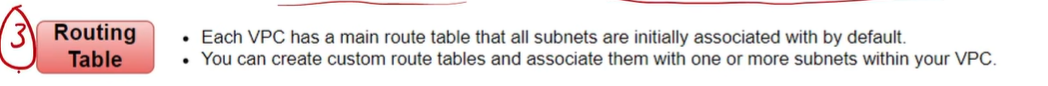

Example:

```text
Destination        Target
--------------------------------
10.0.0.0/16        local
0.0.0.0/0          igw-123456
```

The route:

```text
10.0.0.0/16 → local
```

means:

```text
Traffic inside the VPC stays inside the VPC.
```

The route:

```text
0.0.0.0/0 → Internet Gateway
```

means:

```text
Traffic to other IPv4 destinations can go toward the Internet Gateway.
```

---

## 7.11 Local Route

Every VPC route table includes a local route.

Example:

```text
10.0.0.0/16 → local
```

This allows resources within the VPC to communicate through VPC routing.

Example:

```text
EC2-A
10.0.1.10
    |
    | VPC local routing
    |
EC2-B
10.0.2.20
```

---

## 7.12 Default Route

A common route is:

```text
0.0.0.0/0
```

This means:

```text
Any IPv4 destination
```

For example:

```text
0.0.0.0/0 → Internet Gateway
```

means:

```text
Send traffic for destinations not matched by a more specific route toward the Internet Gateway.
```

---

## 7.13 Longest Prefix Match

AWS route tables use the most specific matching route.

Suppose we have:

```text
Destination        Target
--------------------------------
10.0.0.0/16        local
10.0.1.0/24        Target-A
0.0.0.0/0          IGW
```

Traffic going to:

```text
10.0.1.50
```

matches both:

```text
10.0.0.0/16
```

and:

```text
10.0.1.0/24
```

AWS selects:

```text
10.0.1.0/24
```

because it is more specific.

This is called:

```text
Longest Prefix Match
```

---

## 7.14 Security Groups

A **Security Group** is a virtual firewall that controls traffic to and from resources such as EC2 instances.

Architecture:

```text
Internet
   |
Security Group
   |
EC2
```

Security Groups contain:

```text
Inbound rules
Outbound rules
```

Example inbound rules for a web server:

```text
HTTP
Port: 80
Source: 0.0.0.0/0

HTTPS
Port: 443
Source: 0.0.0.0/0

SSH
Port: 22
Source: My-IP/32
```

---

## 7.15 Security Groups Are Stateful

Security Groups are **stateful**.

Suppose a request is allowed:

```text
Client
   |
   | Request
   v
EC2
```

The response traffic is automatically allowed.

```text
Client
   ^
   | Response
   |
EC2
```

You do not have to create a separate rule specifically for response traffic.

Remember:

```text
Security Group
=
Stateful
```

---

## 7.16 Security Groups Use Allow Rules

Security Groups support allow rules.

For example:

```text
Allow HTTP
Allow HTTPS
Allow SSH
```

You do not create explicit deny rules in Security Groups.

Anything not allowed is implicitly blocked.

---

## 7.17 Network ACL

A **Network Access Control List (NACL)** provides another layer of network security.

A NACL operates at the **subnet level**.

Architecture:

```text
Internet
   |
   v
Network ACL
   |
   v
Subnet
   |
   v
Security Group
   |
   v
EC2
```

---

## 7.18 Security Group vs Network ACL

| Feature | Security Group | Network ACL |
|---|---|---|
| Applied to | Resource/ENI | Subnet |
| Stateful | Yes | No |
| Allow rules | Yes | Yes |
| Deny rules | No | Yes |
| Rule evaluation | All relevant rules | Rule-number order |

The most important exam difference is:

```text
Security Group
=
Stateful
```

while:

```text
Network ACL
=
Stateless
```

---

## 7.19 NACLs Are Stateless

Because NACLs are stateless, request and response traffic are evaluated separately.

Example:

```text
Client
   |
Request
   v
NACL
   |
EC2
```

The return traffic must also be allowed.

```text
Client
   ^
Response
   |
NACL
   |
EC2
```

---

## 7.20 NAT Gateway

Suppose an EC2 instance is inside a private subnet.


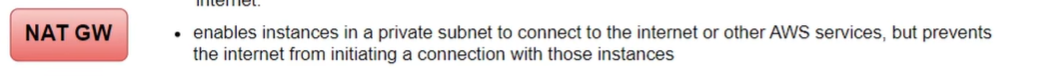

The EC2 instance needs to:

```text
Download updates
Install packages
Access public APIs
Reach external services
```

but you do not want users on the internet to initiate direct connections to it.

You can use a **NAT Gateway**.

Architecture:

```text
Private EC2
    |
    v
Private Route Table
    |
    v
NAT Gateway
    |
    v
Public Subnet
    |
    v
Internet Gateway
    |
    v
Internet
```

---

## 7.21 NAT Gateway Location

A NAT Gateway used for internet access is placed in a **public subnet**.

Example:

```text
VPC

Public Subnet
│
├── NAT Gateway
│
└── Internet Gateway route

Private Subnet
│
└── Private EC2
```

The private subnet route table can contain:

```text
0.0.0.0/0 → NAT Gateway
```

---

## 7.22 NAT Gateway Traffic Flow

Example:

```text
Private EC2
10.0.2.10
     |
     v
Private Route Table
     |
     v
NAT Gateway
     |
     v
Internet Gateway
     |
     v
Internet
```

The private EC2 can initiate the connection.

Internet users generally cannot initiate direct inbound connections through the NAT Gateway to that private EC2.

---

## 7.23 Internet Gateway vs NAT Gateway

### Internet Gateway

Used for public internet connectivity.

```text
Internet
   ⇅
Internet Gateway
   ⇅
Public EC2
```

### NAT Gateway

Used primarily so private resources can initiate outbound connections.

```text
Private EC2
    |
    v
NAT Gateway
    |
    v
Internet
```

Remember:

```text
IGW
=
Public internet connectivity
```

```text
NAT Gateway
=
Outbound internet access for private resources
```

---

> Summary for workflow


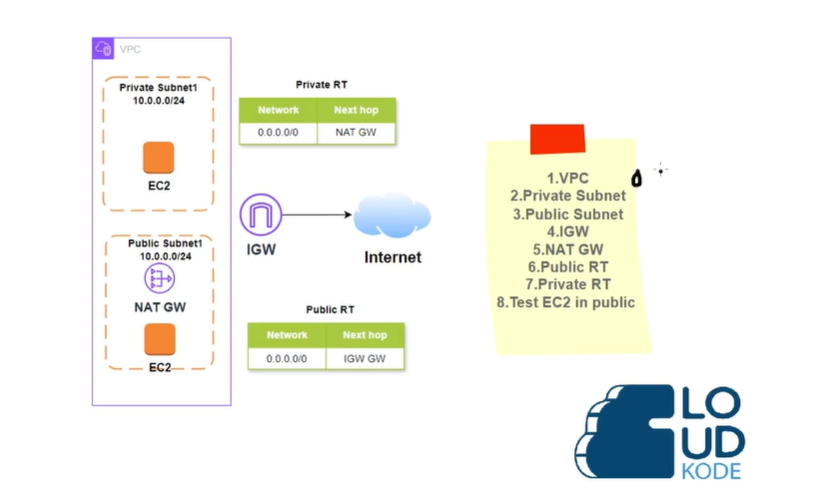



---

## 7.24 Elastic IP

An **Elastic IP (EIP)** is a static public IPv4 address.

Normally, an automatically assigned EC2 public IP can change after certain lifecycle operations.

An Elastic IP is designed to remain associated until you disassociate or release it.

Example:

```text
Elastic IP
3.x.x.x
    |
    v
AWS Resource
```

NAT Gateways commonly use Elastic IP addresses for public IPv4 connectivity.

---

## 7.25 VPC Peering

**VPC Peering** creates private network connectivity between two VPCs.

Example:

```text
VPC-A
10.0.0.0/16

     |
     |
VPC Peering
     |
     |

VPC-B
172.16.0.0/16
```

Resources can communicate using private networking when routing and security rules are properly configured.

The traffic does not need to travel over the public internet.

---

## 7.26 VPC Peering Is Non-Transitive

Consider:

```text
VPC-A ←→ VPC-B ←→ VPC-C
```

This does not automatically mean:

```text
VPC-A ←→ VPC-C
```

VPC Peering is not transitive.

To connect A directly with C, you would need another suitable connection.

Example:

```text
VPC-A ←→ VPC-C
```

This becomes difficult when many VPCs need full connectivity.

---

## 7.27 AWS Transit Gateway

**AWS Transit Gateway (TGW)** acts as a central network hub.

Without Transit Gateway:

```text
VPC-A ----- VPC-B
  |           |
  |           |
VPC-C ----- VPC-D
```

You may need many peering connections.

With Transit Gateway:

```text
          VPC-A
            |
            |
VPC-B ---- TGW ---- VPC-C
            |
            |
          VPC-D
```

Transit Gateway can connect environments such as:

```text
Multiple VPCs
VPN connections
On-premises networks
```

This simplifies larger networking environments.

---

## 7.28 VPC Endpoint

A **VPC Endpoint** allows private connectivity between resources in your VPC and supported AWS services.

Without an endpoint, a private resource might use:

```text
EC2
 |
NAT Gateway
 |
Public service endpoint
 |
AWS Service
```

With a VPC Endpoint:

```text
Private EC2
     |
     v
VPC Endpoint
     |
     v
AWS Service
```

This can remove the need for public internet connectivity for supported service traffic.

---

## 7.29 Gateway Endpoint

Gateway Endpoints are available primarily for:

```text
Amazon S3
Amazon DynamoDB
```

Example:

```text
Private EC2
     |
     v
Route Table
     |
     v
Gateway Endpoint
     |
     v
Amazon DynamoDB
```

This is especially useful for applications in private subnets.

Example:

```text
EC2
Private Subnet
      |
      v
DynamoDB Gateway Endpoint
      |
      v
DynamoDB
```

No NAT Gateway is required specifically for that DynamoDB traffic.

---

## 7.30 Interface Endpoint

Many AWS services can be privately accessed using **Interface Endpoints**.

Interface Endpoints use:

```text
AWS PrivateLink
```

Conceptually:

```text
Private EC2
     |
     v
Private IP
     |
     v
Interface Endpoint
     |
     v
AWS PrivateLink
     |
     v
AWS Service
```

An Interface Endpoint creates network interfaces inside the VPC.

---

## 7.31 Gateway Endpoint vs Interface Endpoint

### Gateway Endpoint

Common services:

```text
S3
DynamoDB
```

Conceptually:

```text
Route Table
   |
Gateway Endpoint
   |
AWS Service
```

### Interface Endpoint

Used by many other AWS services.

Conceptually:

```text
EC2
 |
Private IP
 |
Interface Endpoint
 |
PrivateLink
 |
AWS Service
```

---

## 7.32 DNS Inside a VPC

AWS provides DNS functionality through **Route 53 Resolver**.

Instead of connecting directly to:

```text
10.0.2.25
```

an application may use a DNS name such as:

```text
database.internal
```

Conceptually:

```text
Application
    |
DNS Name
    |
Route 53 Resolver
    |
IP Address
    |
Database
```

DNS makes systems easier to manage because applications do not need to depend directly on fixed IP addresses.

---

## 7.33 VPC Flow Logs

**VPC Flow Logs** capture information about IP traffic going to and from network interfaces.

They can help troubleshoot networking issues.

For example:

```text
Why can't EC2-A connect to EC2-B?

Is traffic reaching the subnet?

Is a connection being accepted?

Is traffic being rejected?

Which IP addresses are communicating with my resources?
```

Flow Logs can be configured at levels such as:

```text
VPC
Subnet
Network Interface
```

Logs can be delivered to destinations such as:

```text
CloudWatch Logs
Amazon S3
```

---

## 7.34 Practical VPC Lab

Now let's build a simple VPC.

Our architecture will be:

```text
VPC
10.0.0.0/16

├── Public Subnet
│   10.0.1.0/24
│
└── Private Subnet
    10.0.2.0/24
```

---

## 7.35 Step 1 — Create the VPC

Open:

```text
AWS Console
→ VPC
→ Your VPCs
→ Create VPC
```

Configure:

```text
Name:

MyLab-VPC
```

IPv4 CIDR:

```text
10.0.0.0/16
```

Create the VPC.

Architecture:

```text
AWS
 |
MyLab-VPC
10.0.0.0/16
```

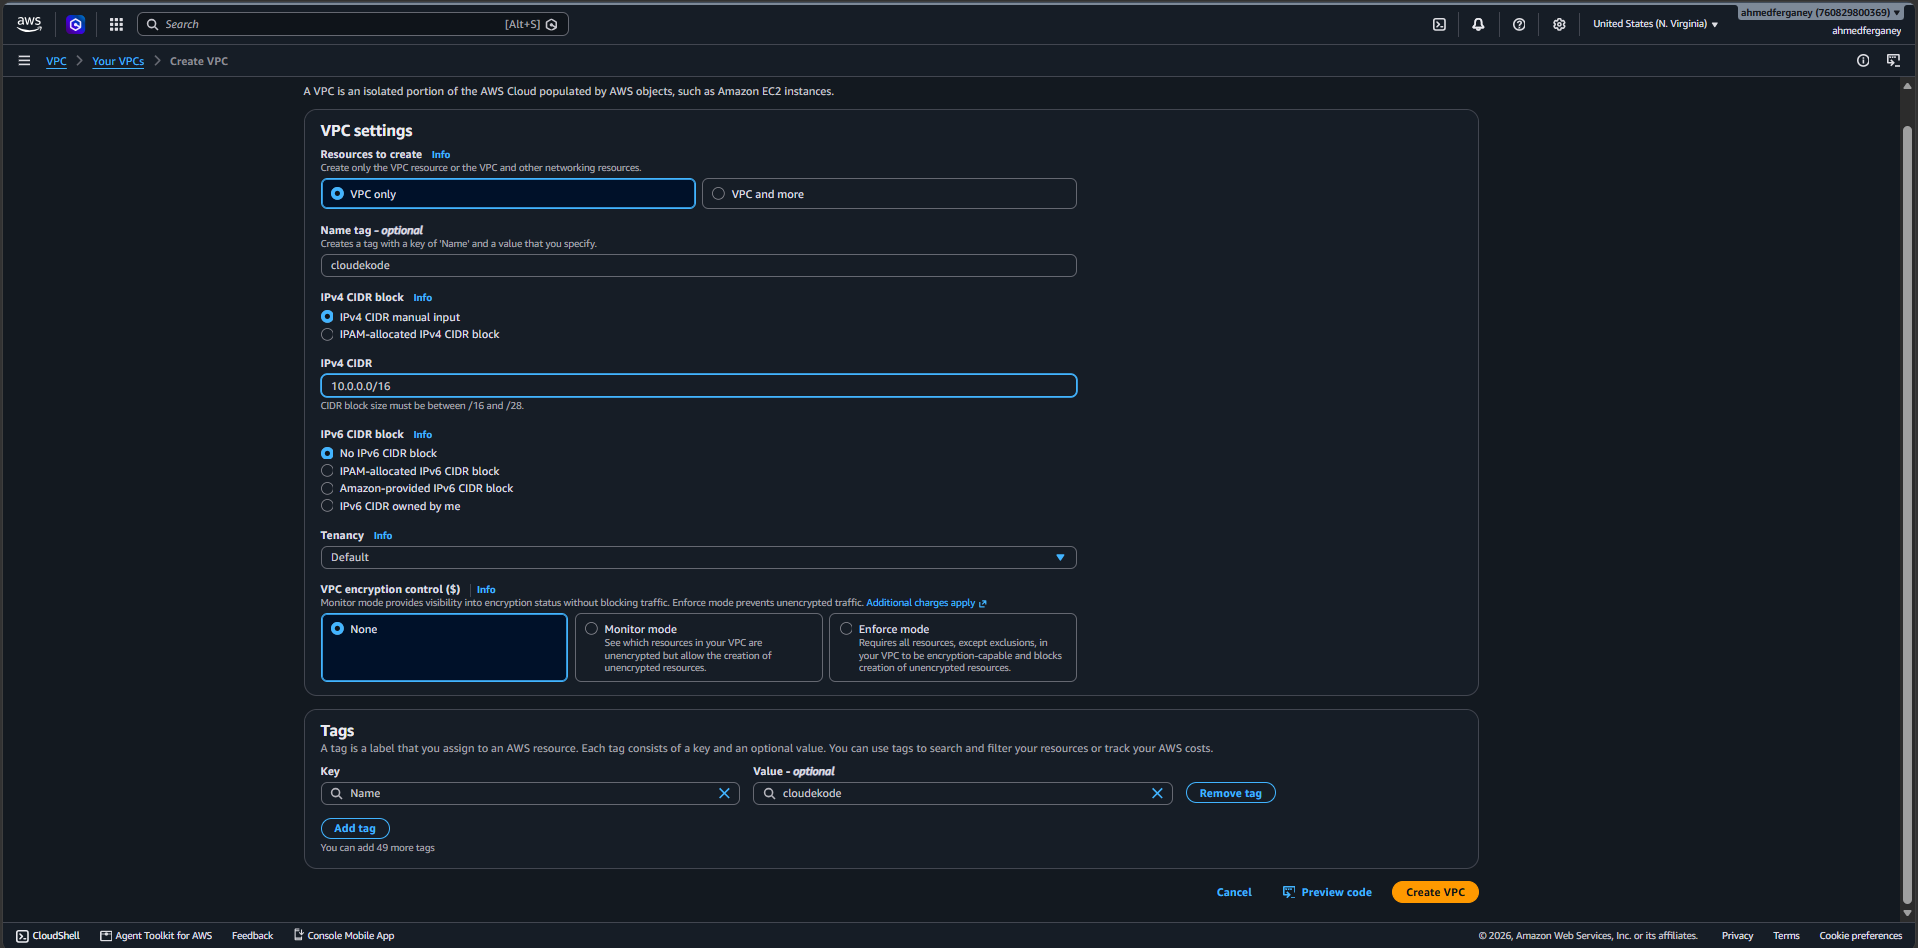

---

## 7.36 Step 2 — Create Public Subnet

Open:

```text
VPC
→ Subnets
→ Create subnet
```

Configure:

```text
VPC:

MyLab-VPC
```

Name:

```text
Public-Subnet
```

CIDR:

```text
10.0.1.0/24
```

Architecture:

```text
MyLab-VPC
10.0.0.0/16

└── Public-Subnet
    10.0.1.0/24
```

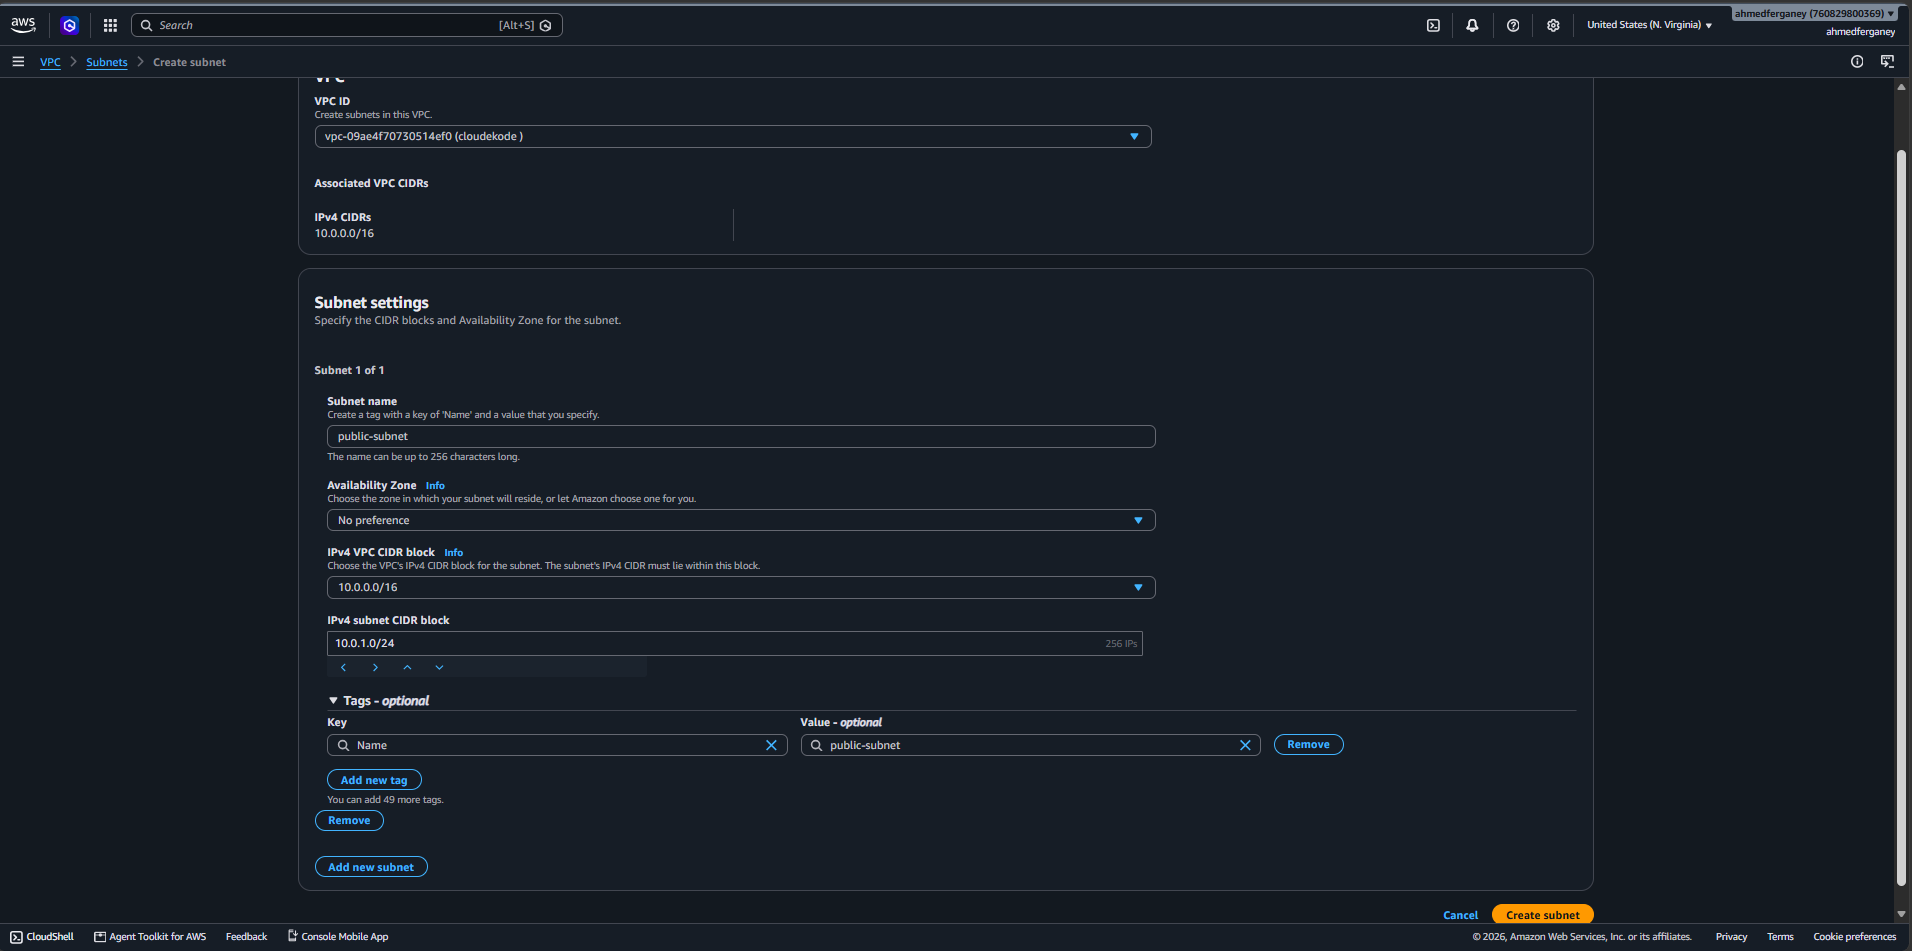

---

## 7.37 Step 3 — Create Private Subnet

Create another subnet.

Name:

```text
Private-Subnet
```

CIDR:

```text
10.0.2.0/24
```

Architecture:

```text
MyLab-VPC
10.0.0.0/16

├── Public-Subnet
│   10.0.1.0/24
│
└── Private-Subnet
    10.0.2.0/24
```

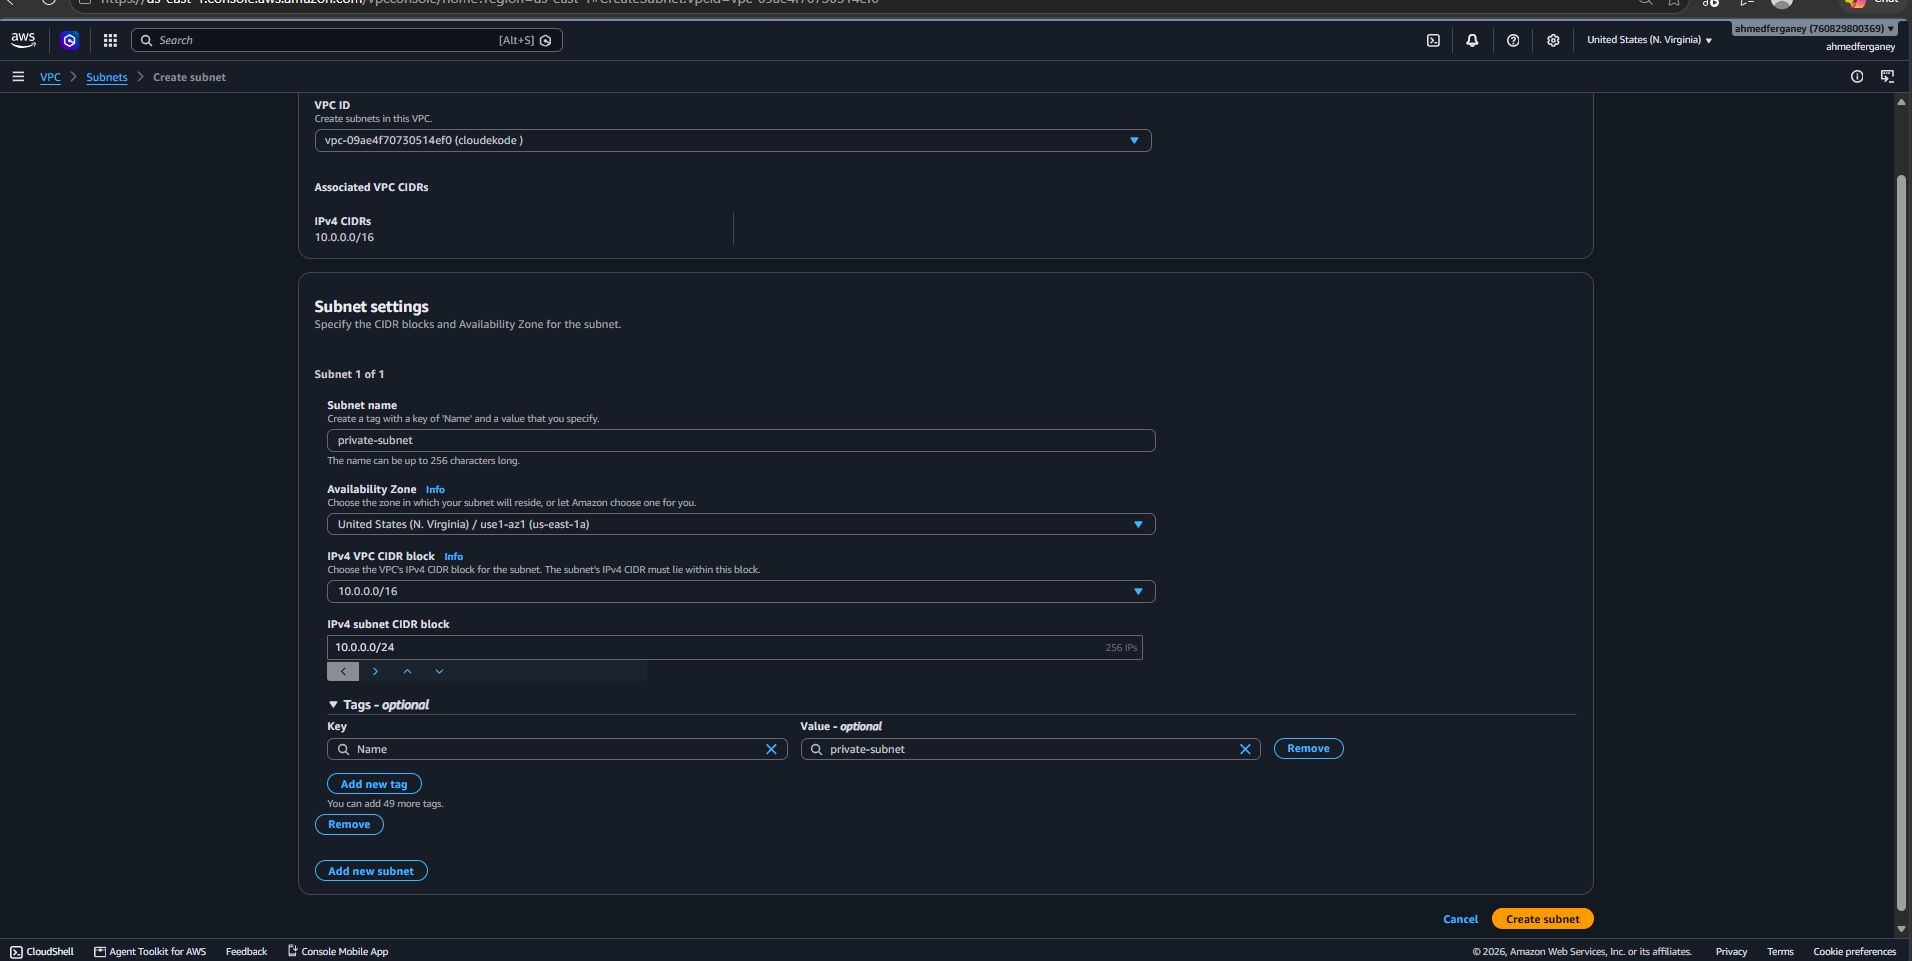

---

## 7.38 Step 4 — Create Internet Gateway

Open:

```text
VPC
→ Internet Gateways
→ Create Internet Gateway
```

Name:

```text
MyLab-IGW
```

Then:

```text
Actions
→ Attach to VPC
→ MyLab-VPC
```

Architecture:

```text
Internet
   |
MyLab-IGW
   |
MyLab-VPC
```

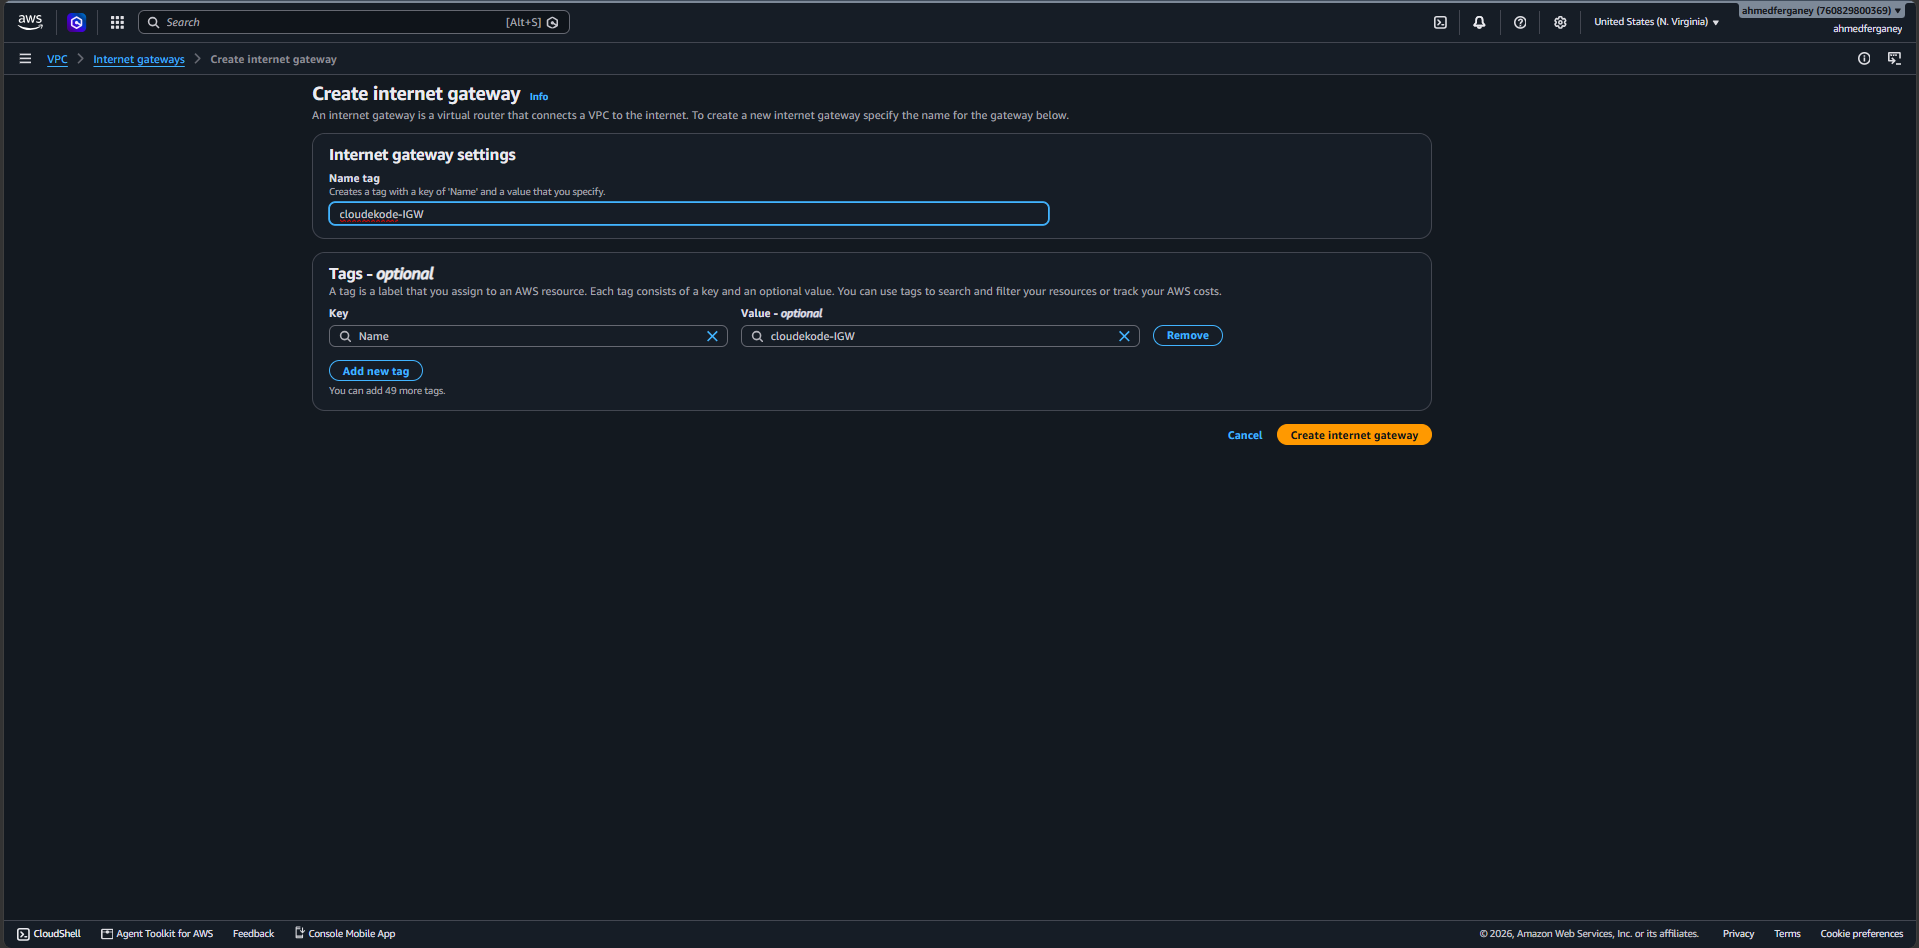

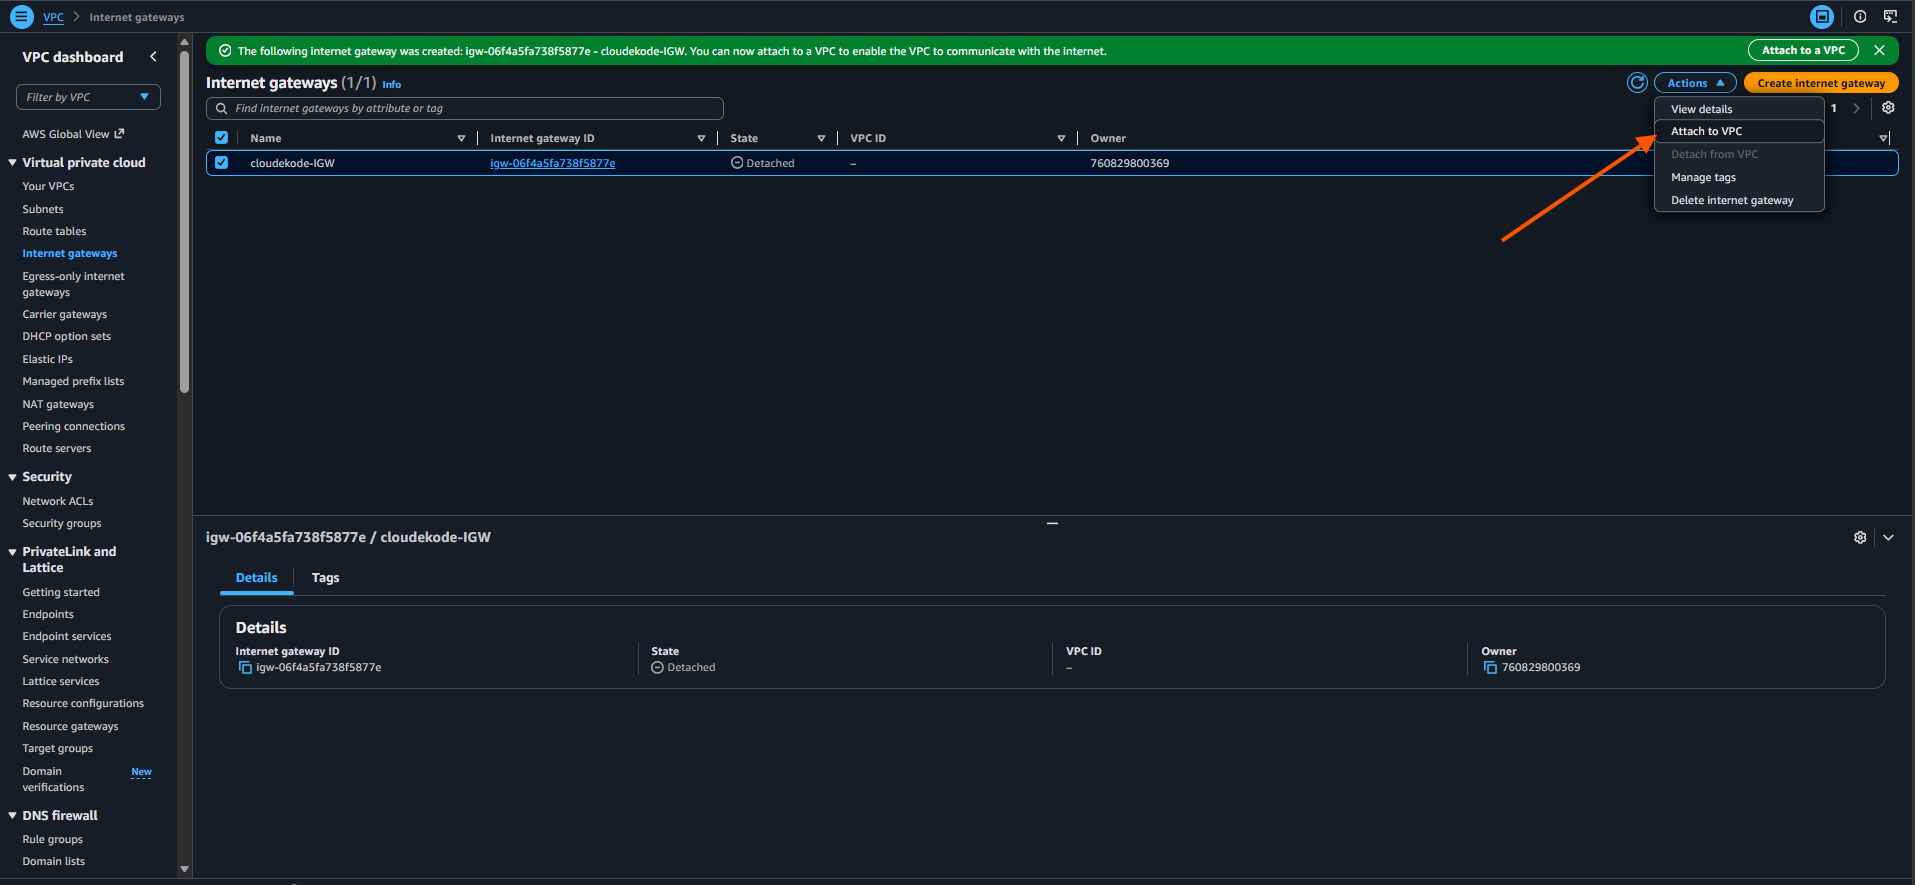

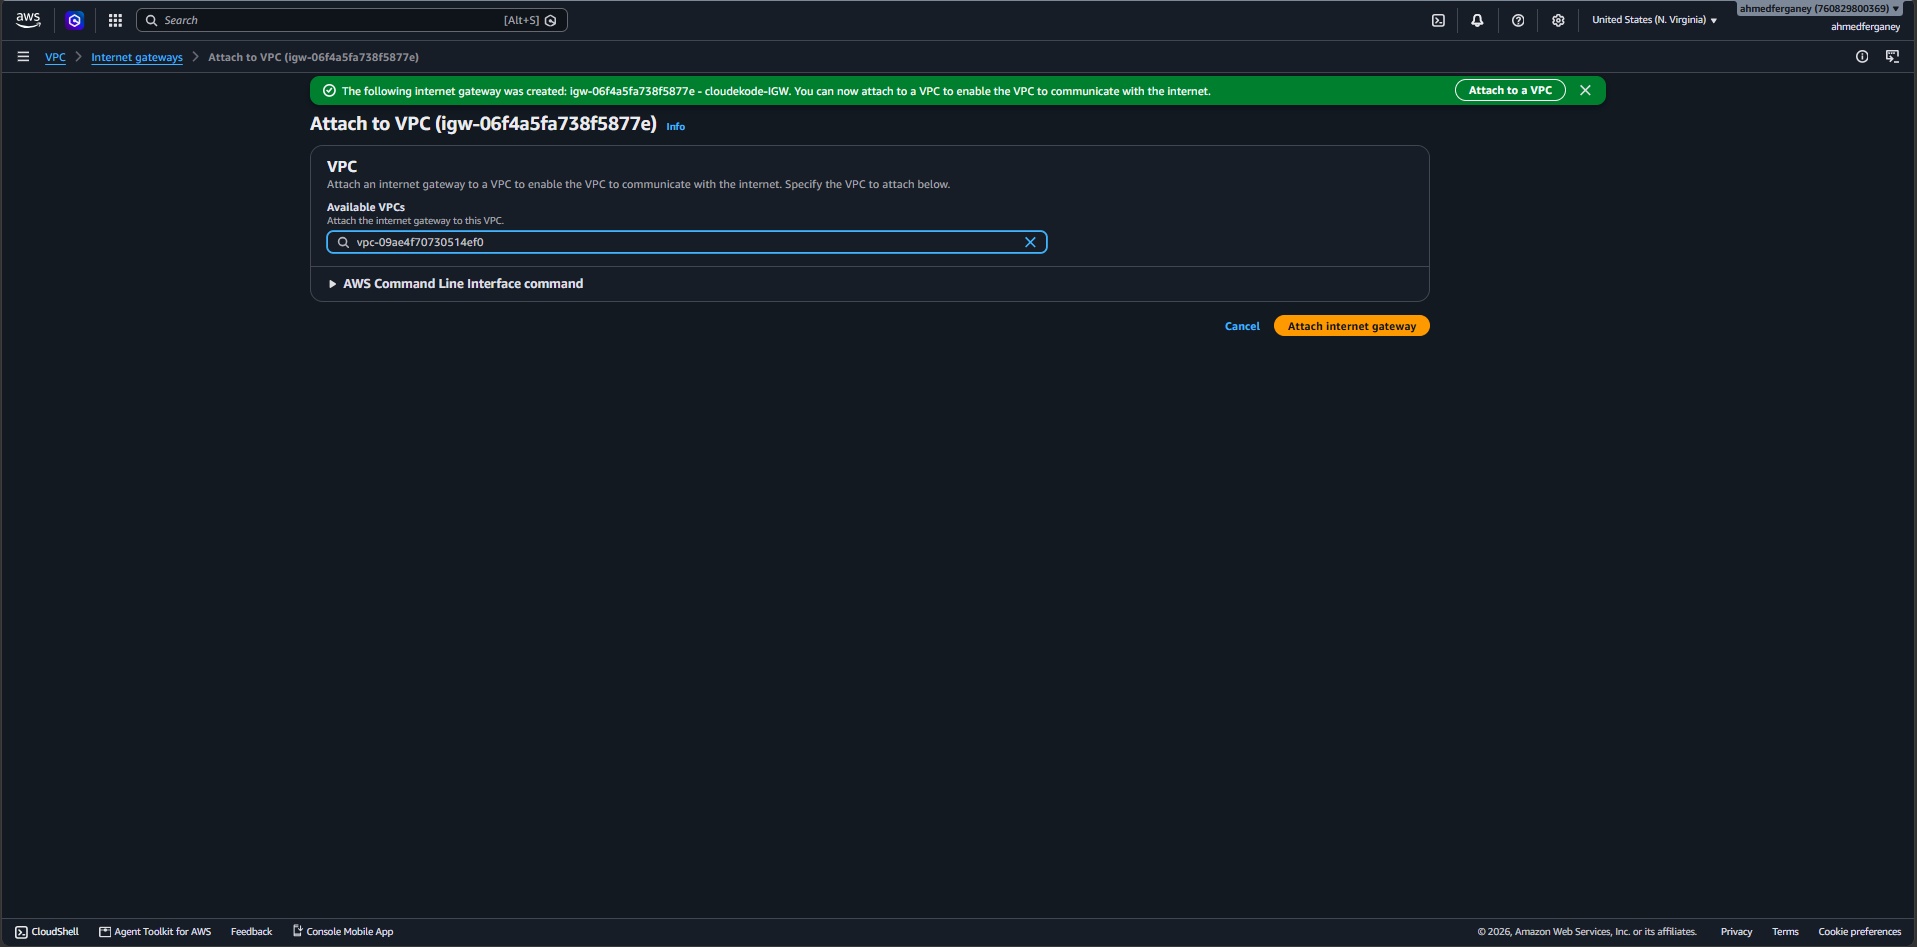

---

## 7.39 Step 5 — Create Public Route Table



> by default we will see default route table

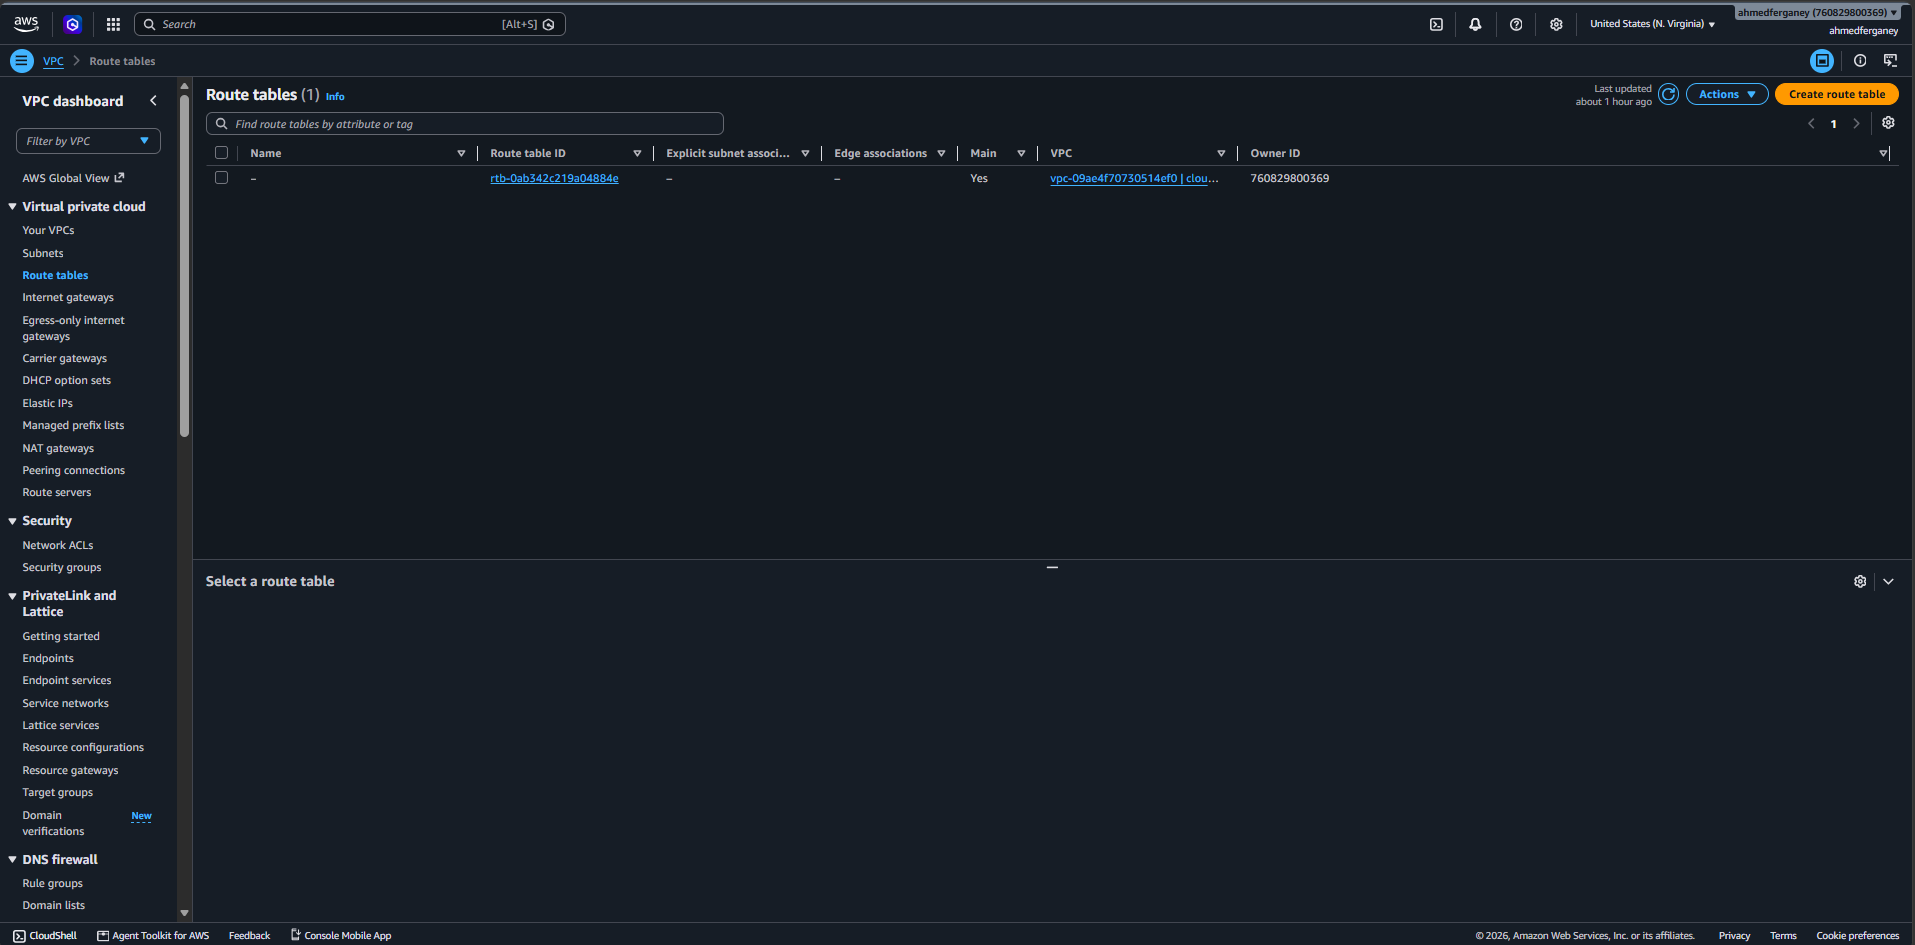

Open:

```text
VPC
→ Route Tables
→ Create Route Table
```

Name:

```text
Public-RT
```

Select:

```text
MyLab-VPC
```


Add the following route:

```text
Destination:

0.0.0.0/0
```

Target:

```text
Internet Gateway
```

Select:

```text
MyLab-IGW
```

Result:

```text
Destination        Target
--------------------------------
10.0.0.0/16        local
0.0.0.0/0          MyLab-IGW
```

---


## 7.40 Step 6 — Associate Public Subnet

Associate:

```text
Public-Subnet
```

with:

```text
Public-RT
```

Architecture:

```text
Internet
    |
MyLab-IGW
    |
Public-RT
    |
Public-Subnet
```

Now the subnet has a route to the internet.

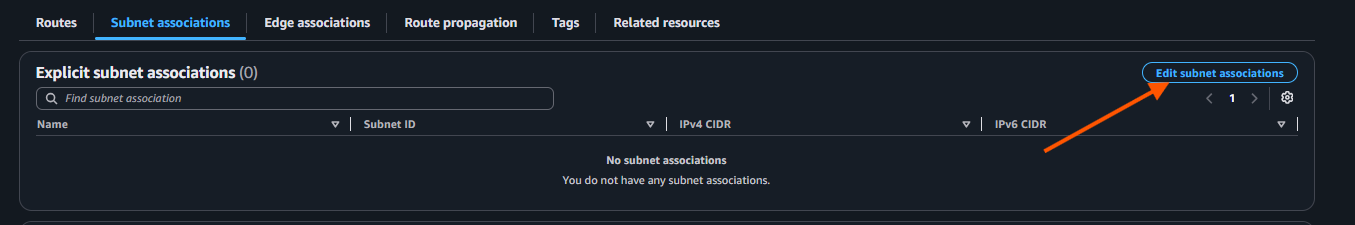

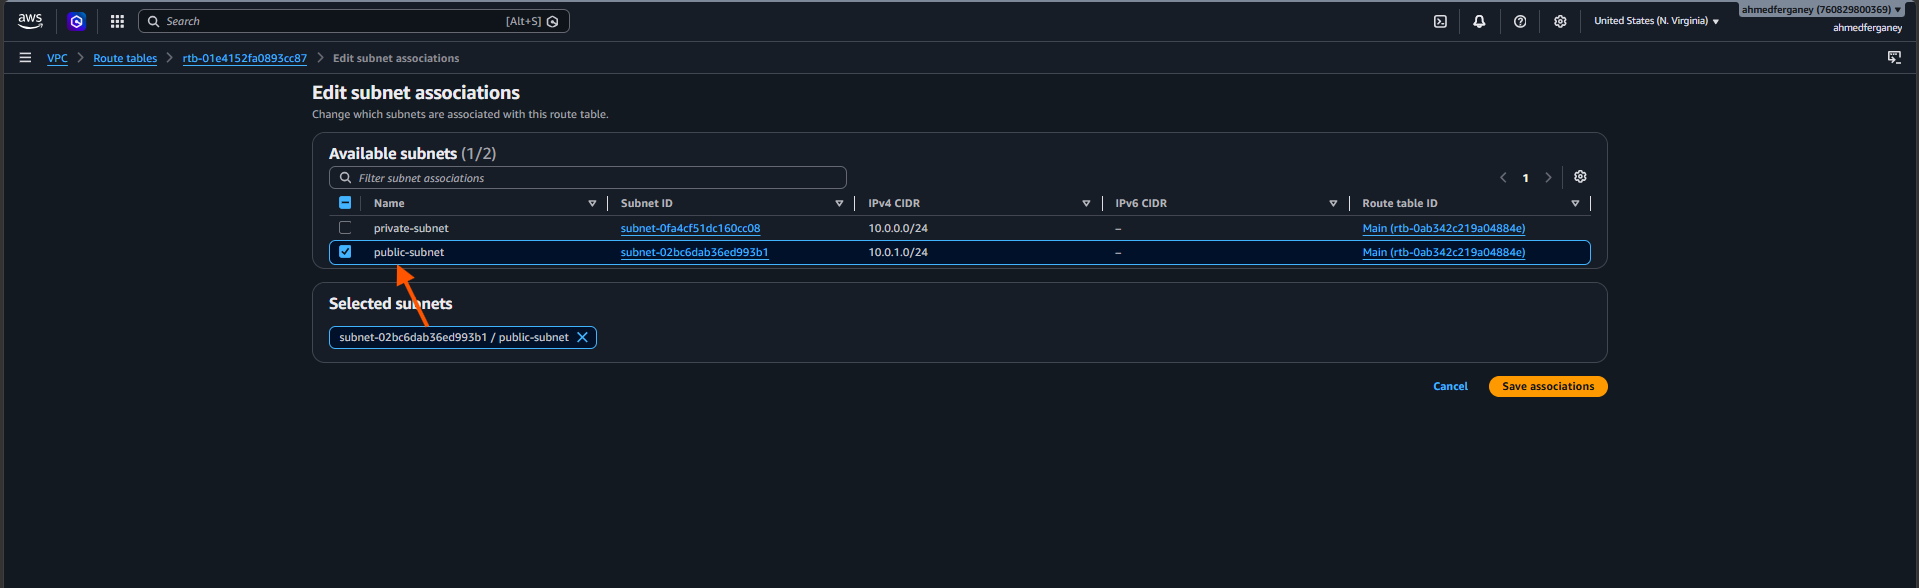



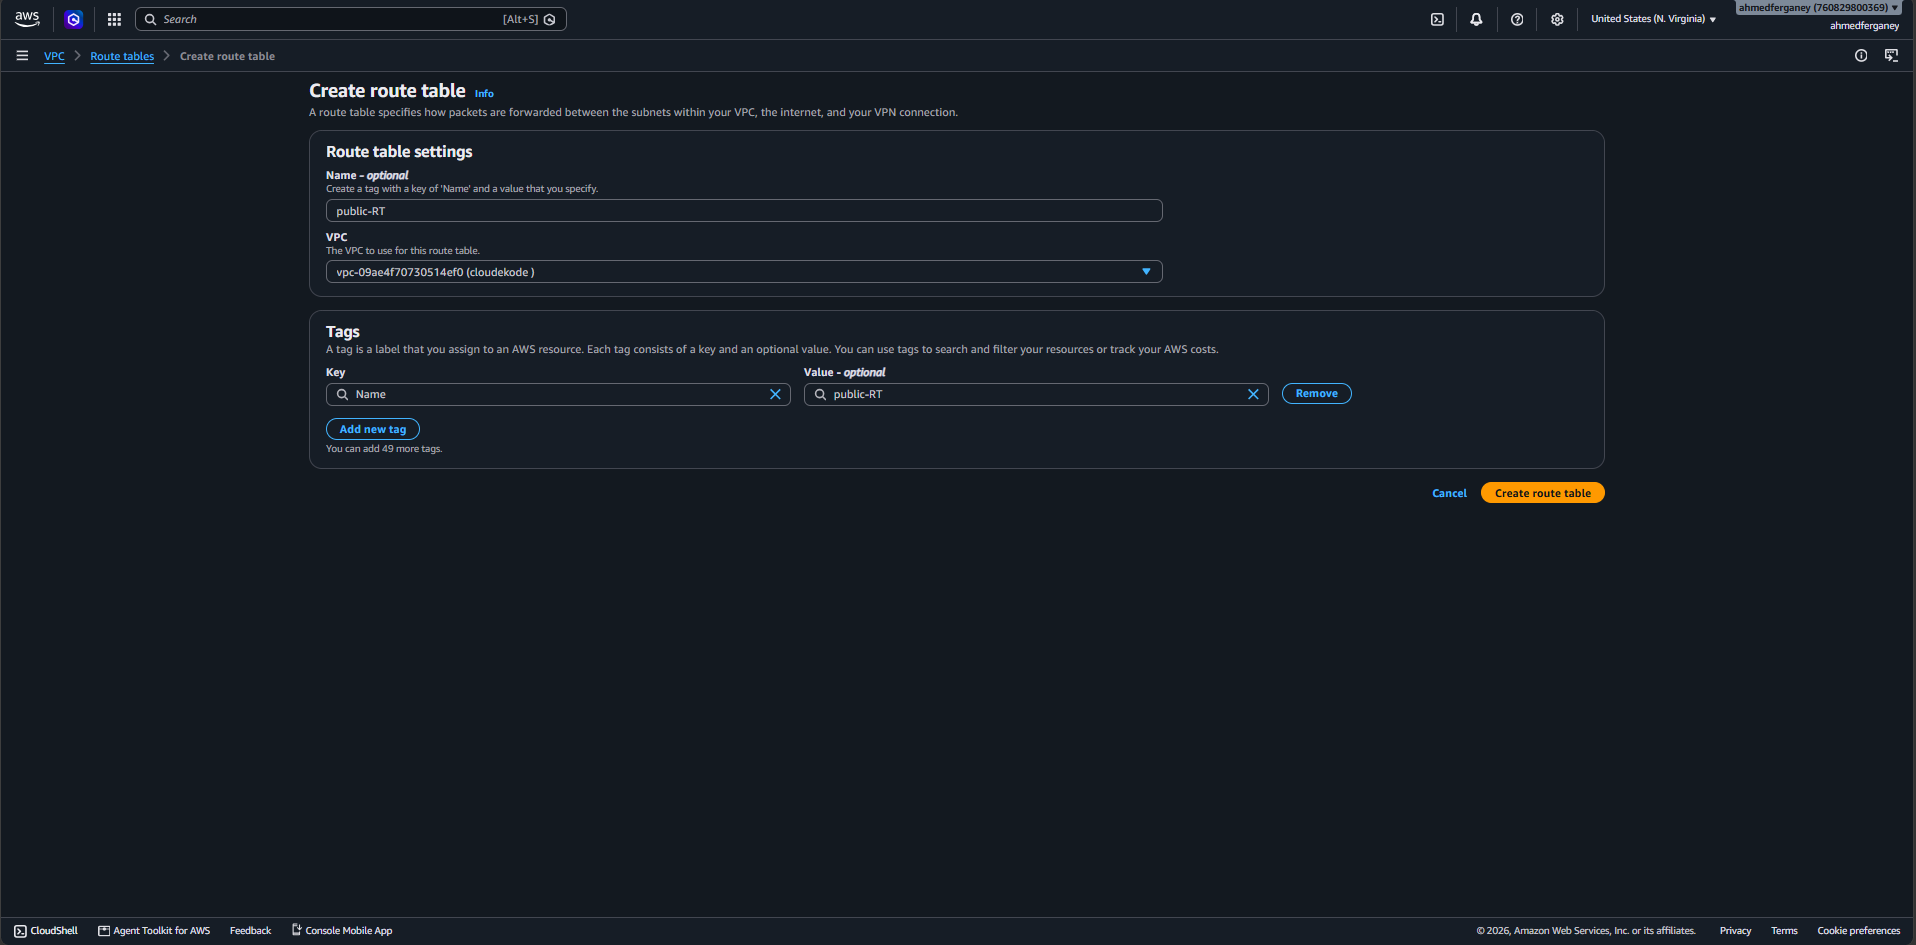



---

## 7.41 Step 7 — Launch Public EC2

Launch an EC2 instance.

Network:

```text
MyLab-VPC
```

Subnet:

```text
Public-Subnet
```

Enable:

```text
Auto-assign Public IP
```

Example Security Group:

```text
SSH
Port 22
Source: My IP

HTTP
Port 80
Source: 0.0.0.0/0
```

Architecture:

```text
Internet
   |
IGW
   |
Public Route Table
   |
Public Subnet
   |
Public EC2
```

Example:

```text
Private IP:

10.0.1.10

Public IP:

3.x.x.x
```


> make sure that it is attached to public subnet and allow all traific or http

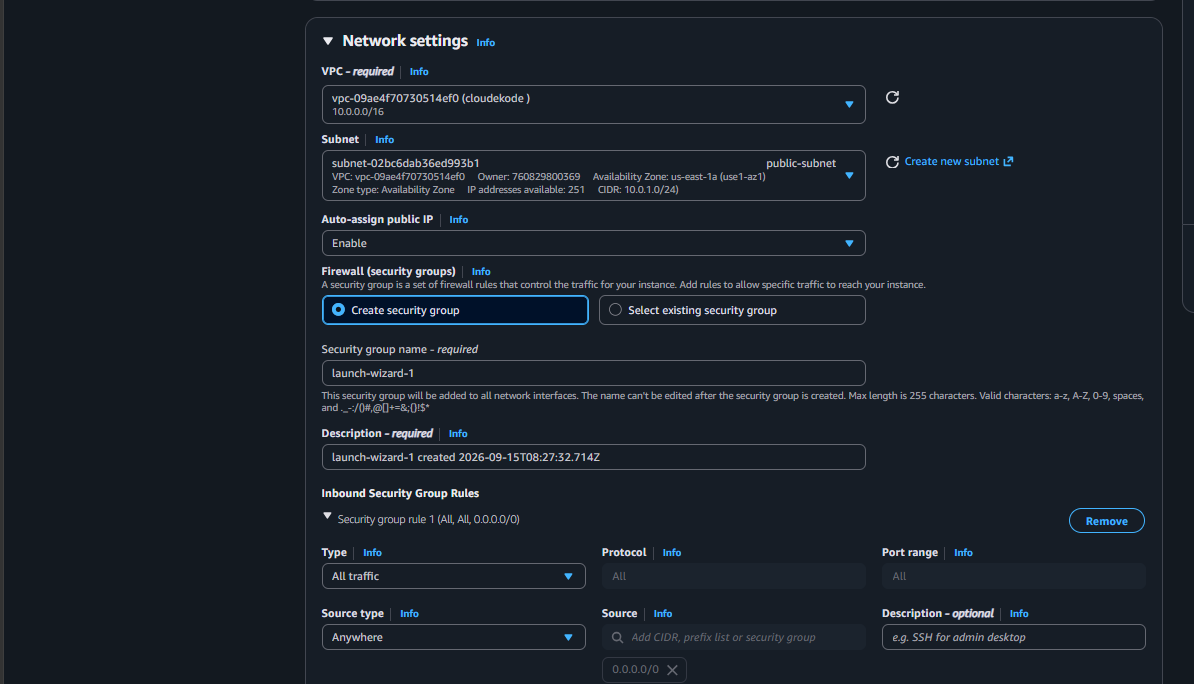

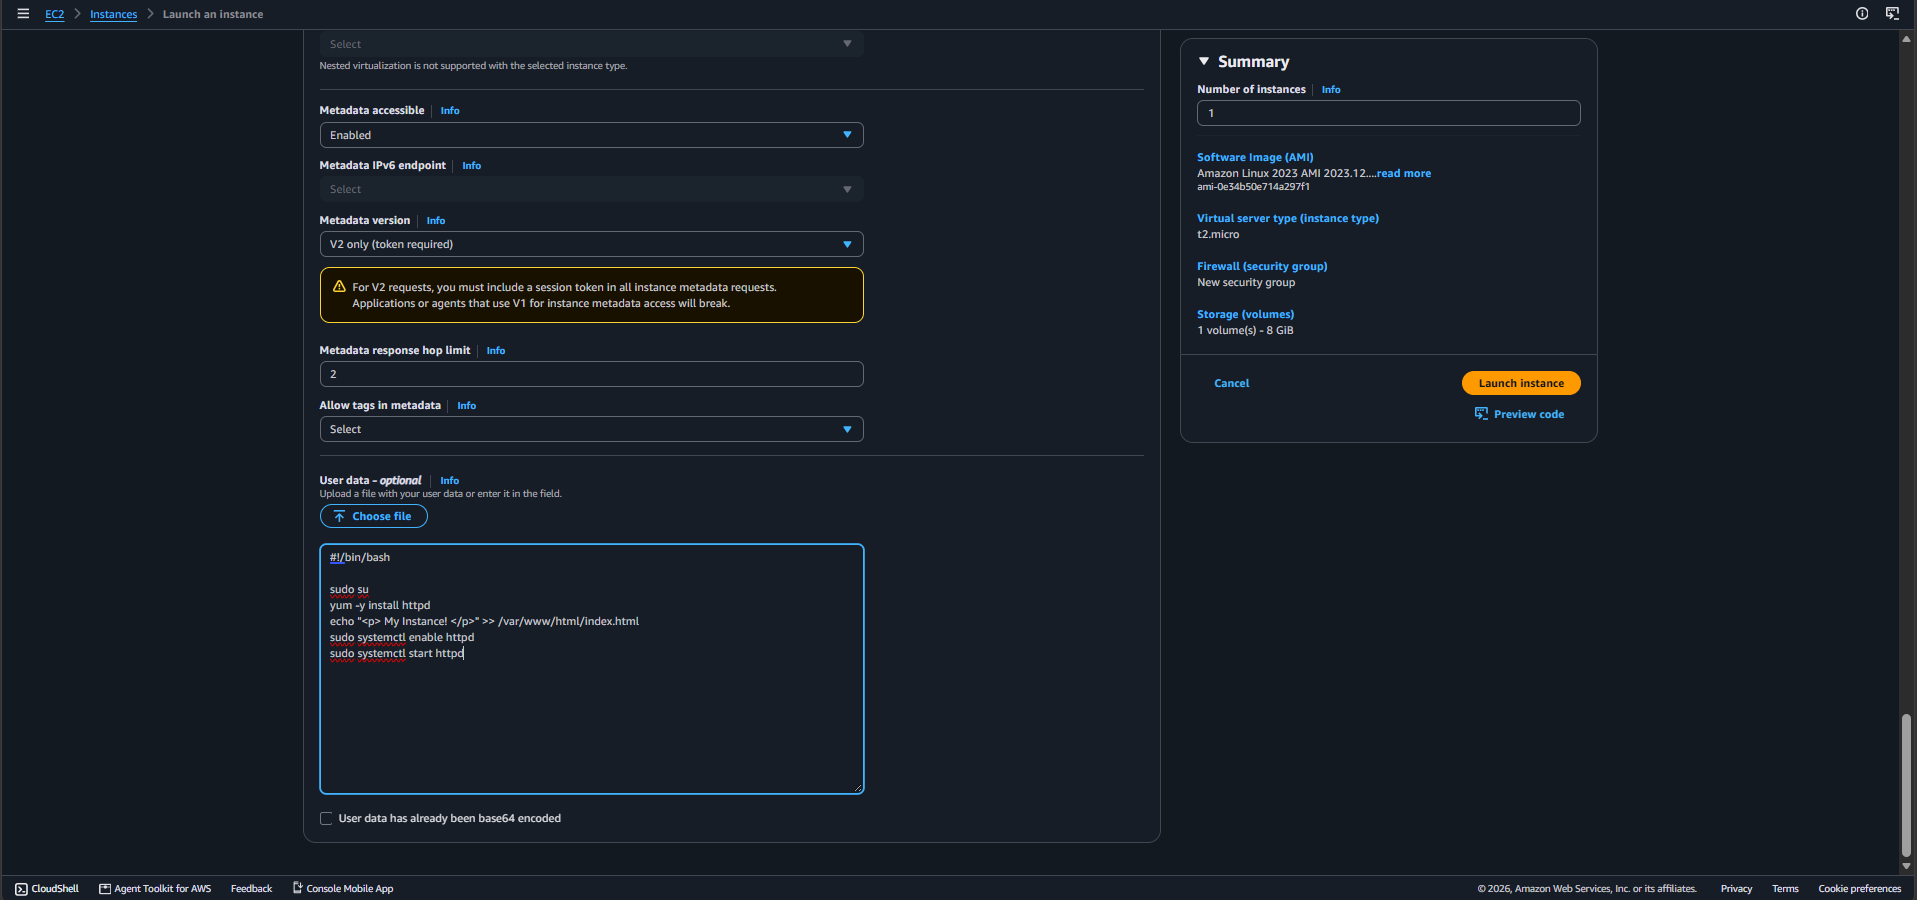

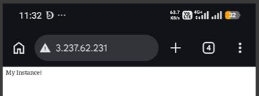

---

## 7.42 Step 8 — Launch Private EC2

Launch another EC2 instance.

Network:

```text
MyLab-VPC
```

Subnet:

```text
Private-Subnet
```

Do not assign a public IPv4 address.

Example:

```text
Private EC2

Private IP:
10.0.2.10

Public IP:
None
```

Architecture:

```text
Private Subnet
      |
      v
Private EC2
10.0.2.10
```

The server is not directly reachable from the public internet.

---

## 7.43 Step 9 — Add a NAT Gateway

If the private EC2 needs outbound internet connectivity, create a NAT Gateway.

Open:

```text
VPC
→ NAT Gateways
→ Create NAT Gateway
```

Place it inside:

```text
Public-Subnet
```

Assign an:

```text
Elastic IP
```

Architecture:

```text
Internet
   |
Internet Gateway
   |
Public Subnet
   |
NAT Gateway
```

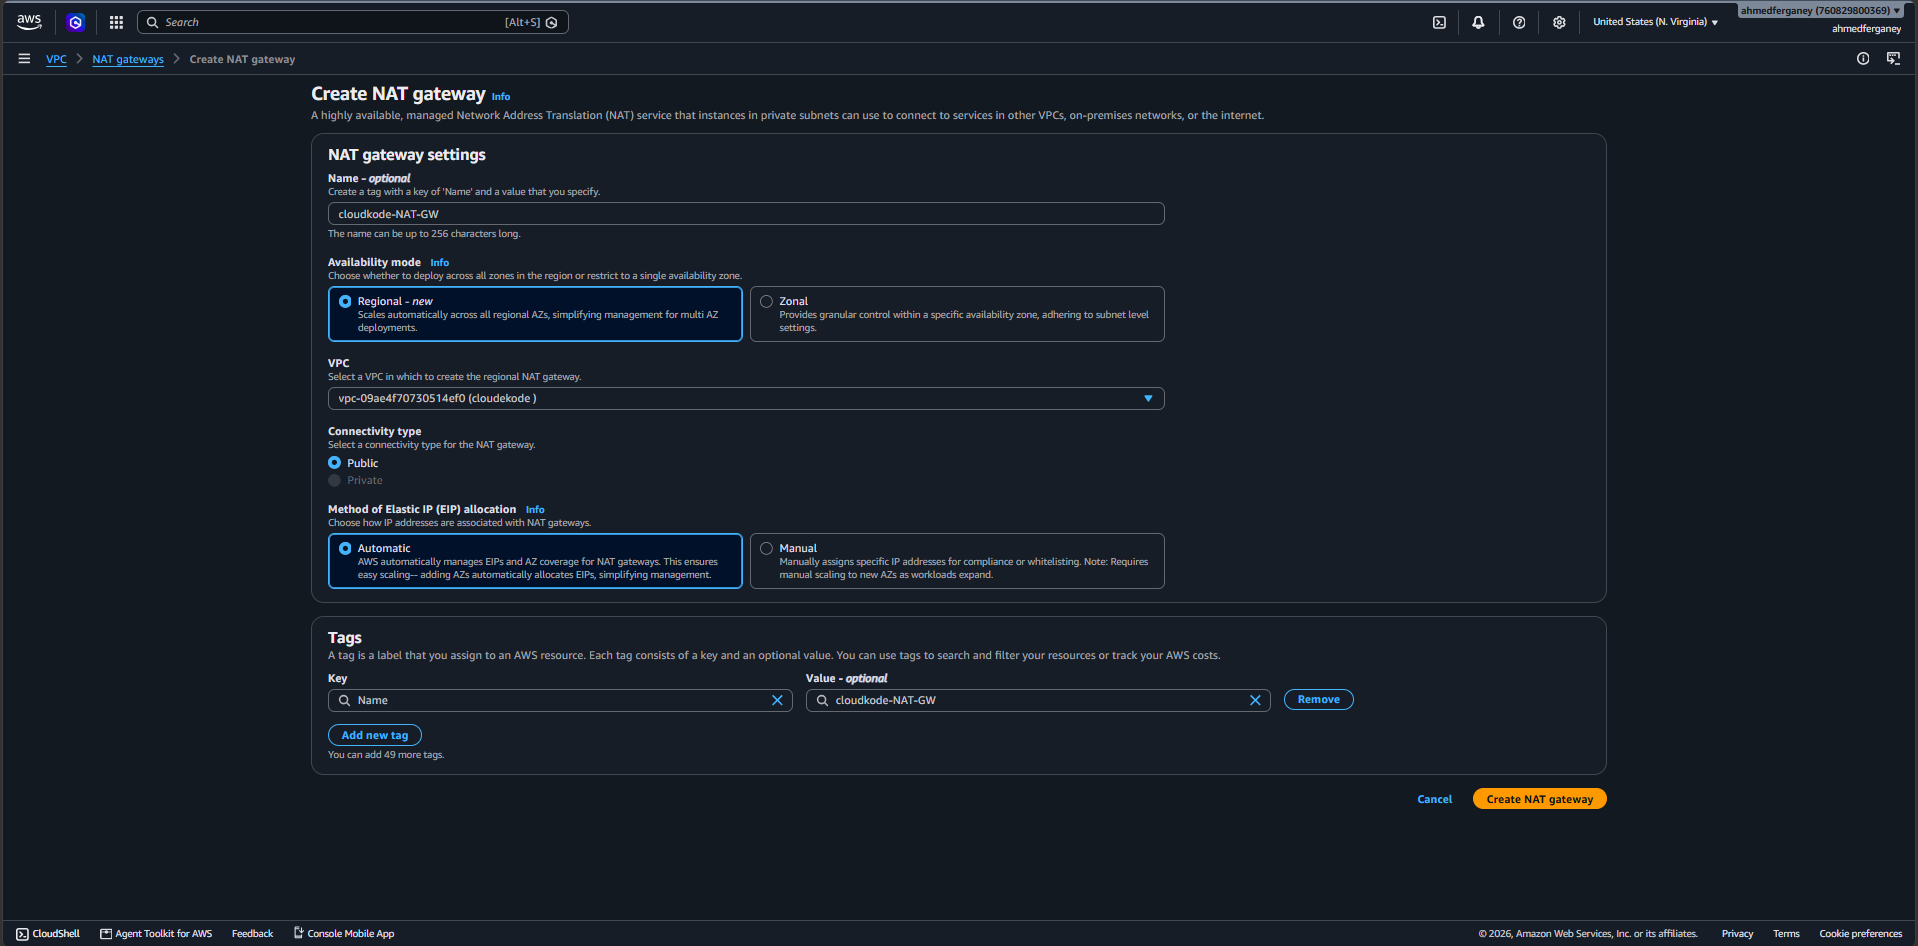


---

## 7.44 Step 10 — Configure Private Route Table

Create:

```text
Private-RT
```

Associate:

```text
Private-Subnet
```

Add:

```text
Destination:

0.0.0.0/0
```

Target:

```text
NAT Gateway
```

Result:

```text
Destination        Target
--------------------------------
10.0.0.0/16        local
0.0.0.0/0          NAT Gateway
```

Now:

```text
Private EC2
    |
Private Route Table
    |
NAT Gateway
    |
Internet Gateway
    |
Internet
```

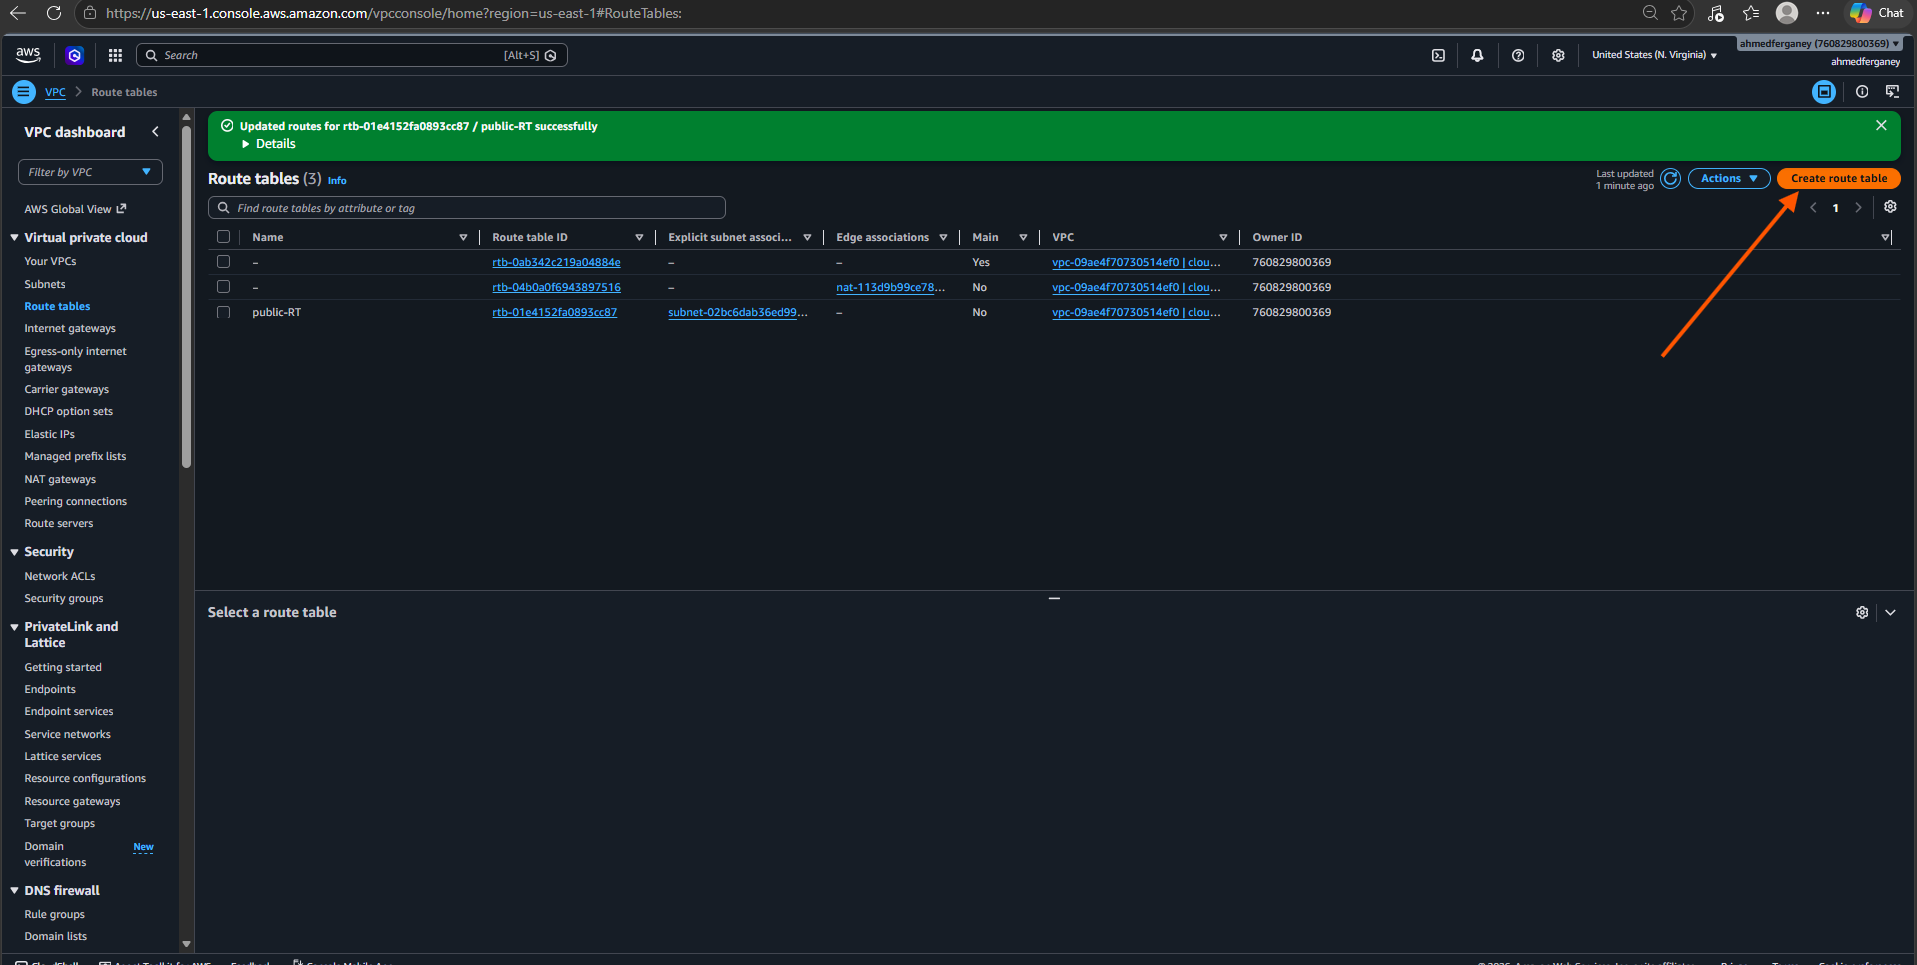

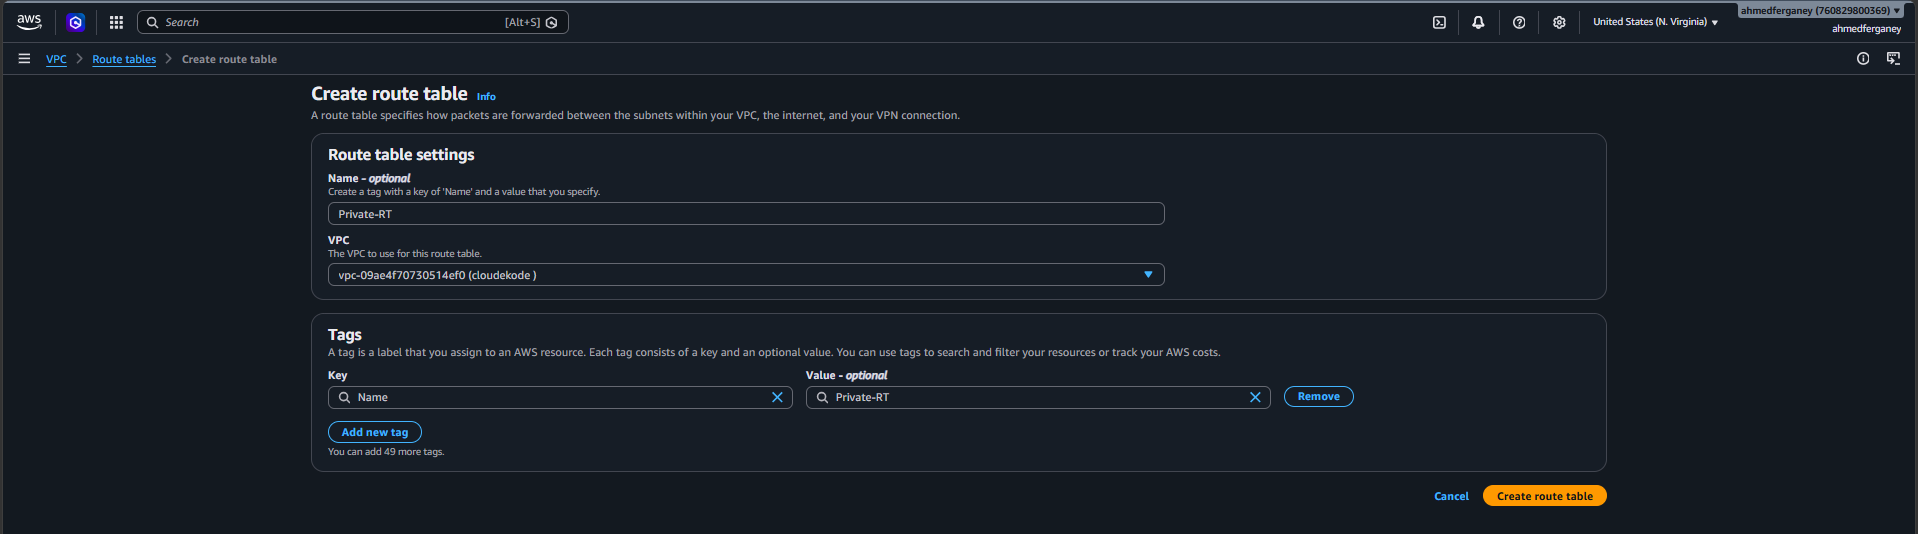


- then subnet assosiation to consider which subnet is part of RT

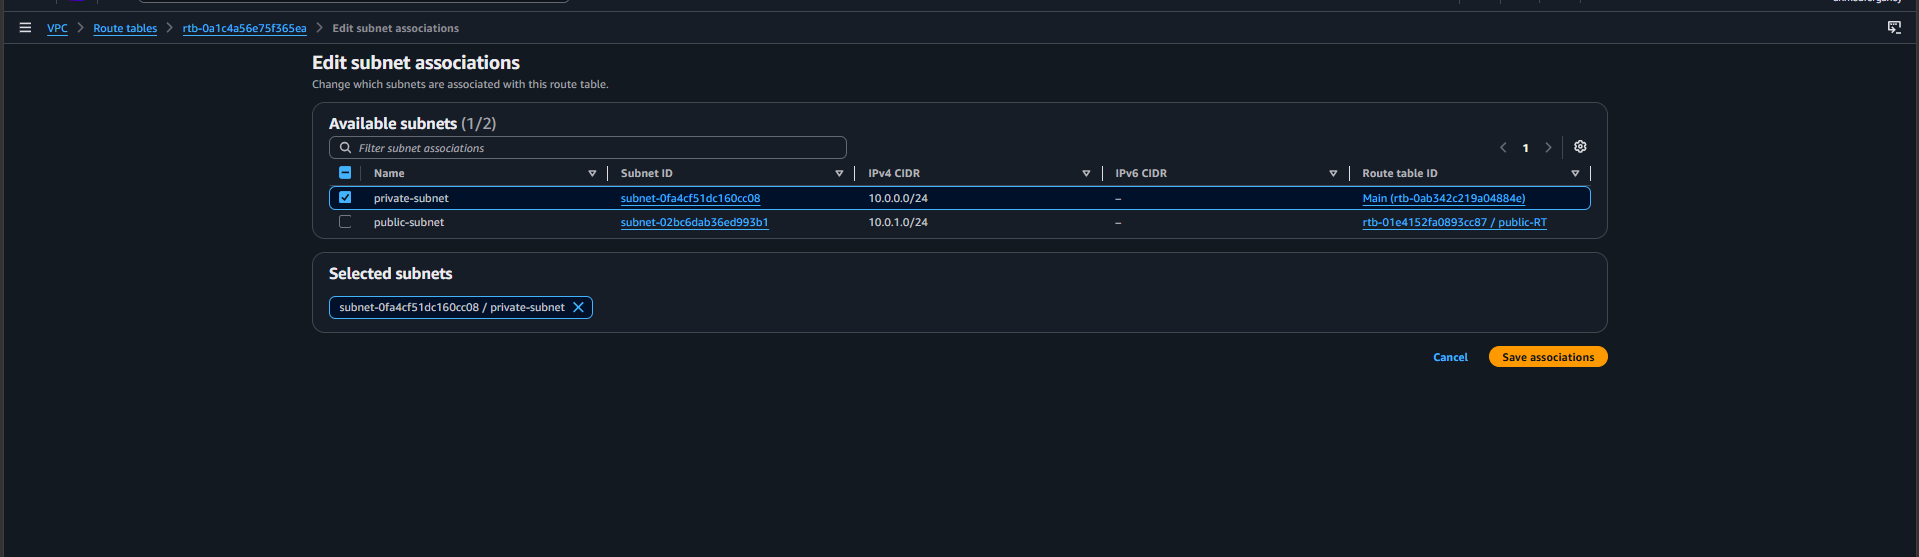

- then edit route

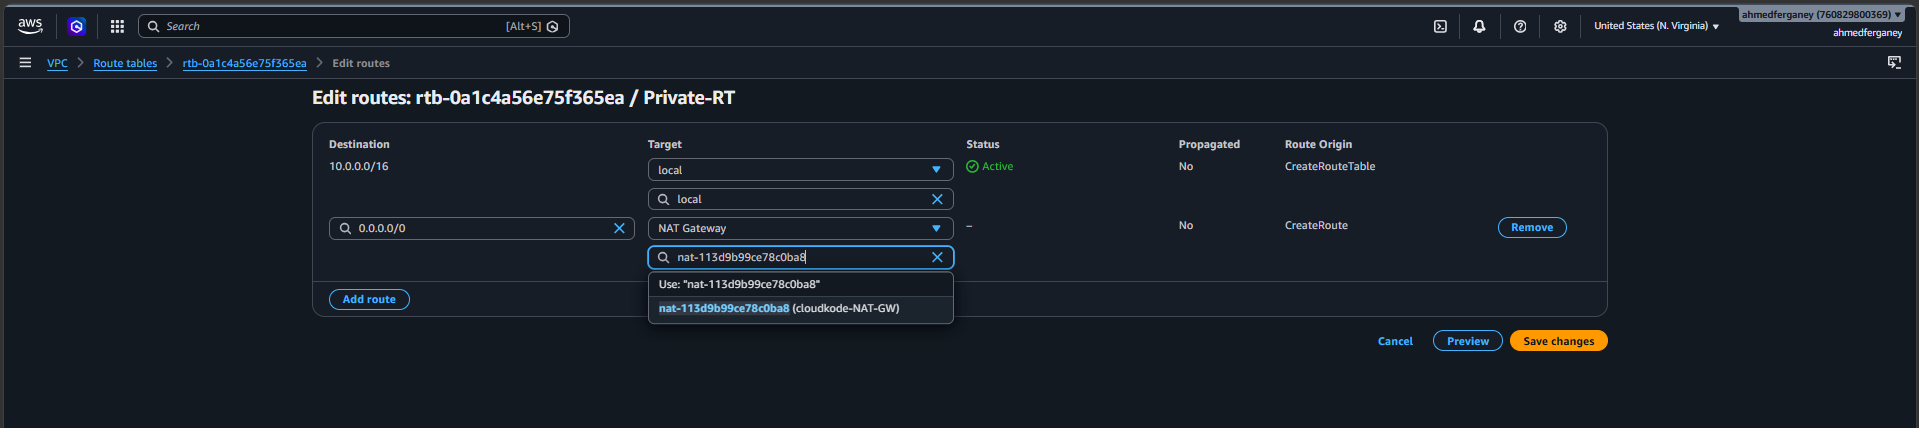


> Edit Route for public


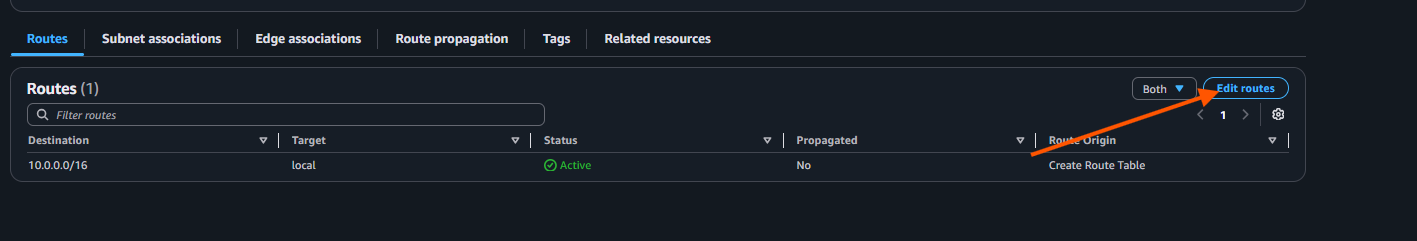

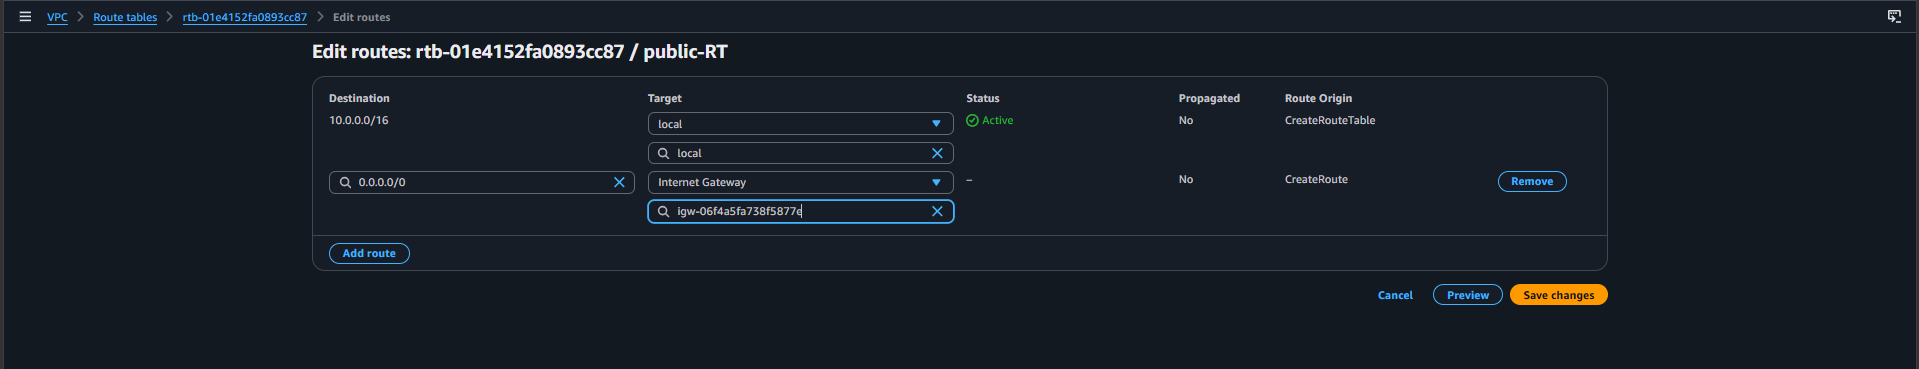



---

## 7.45 Complete VPC Lab Architecture

```text
                          Internet
                             |
                             |
                      Internet Gateway
                             |
                             |
              +--------------+--------------+
              |                             |
              |                      Public Subnet
              |                      10.0.1.0/24
              |                             |
              |                  +----------+----------+
              |                  |                     |
              |              Public EC2            NAT Gateway
              |                                        |
              |                                        |
              |                               Private Route Table
              |                                        |
              |                                        |
              |                                 Private Subnet
              |                                  10.0.2.0/24
              |                                        |
              |                                    Private EC2
              |
              +---------------------------------------------+
                             MyLab-VPC
                            10.0.0.0/16
```

---

## 7.46 Site-to-Site VPN

A **Site-to-Site VPN** connects an on-premises network to AWS through encrypted VPN tunnels over the internet.

Example:

```text
Company Office
192.168.0.0/16
      |
      |
Customer Gateway
      |
      |
========================
Encrypted VPN Tunnel
Public Internet
========================
      |
      |
AWS VPN Gateway
      |
      |
AWS VPC
10.0.0.0/16
```

This is a common type of **hybrid cloud** connectivity.

---

## 7.47 Customer Gateway

A **Customer Gateway** represents the customer side of the VPN connection.

This may represent equipment such as:

```text
Router
Firewall
VPN appliance
```

Example:

```text
Company Network
      |
Customer Gateway
      |
VPN
      |
AWS
```

---

## 7.48 Virtual Private Gateway

A **Virtual Private Gateway (VGW)** can represent the AWS side of a traditional Site-to-Site VPN connection.

Architecture:

```text
On-Premises
     |
Customer Gateway
     |
Public Internet
     |
Encrypted VPN
     |
Virtual Private Gateway
     |
AWS VPC
```

---

> Site-to-Site VPN VS  Direct Connect

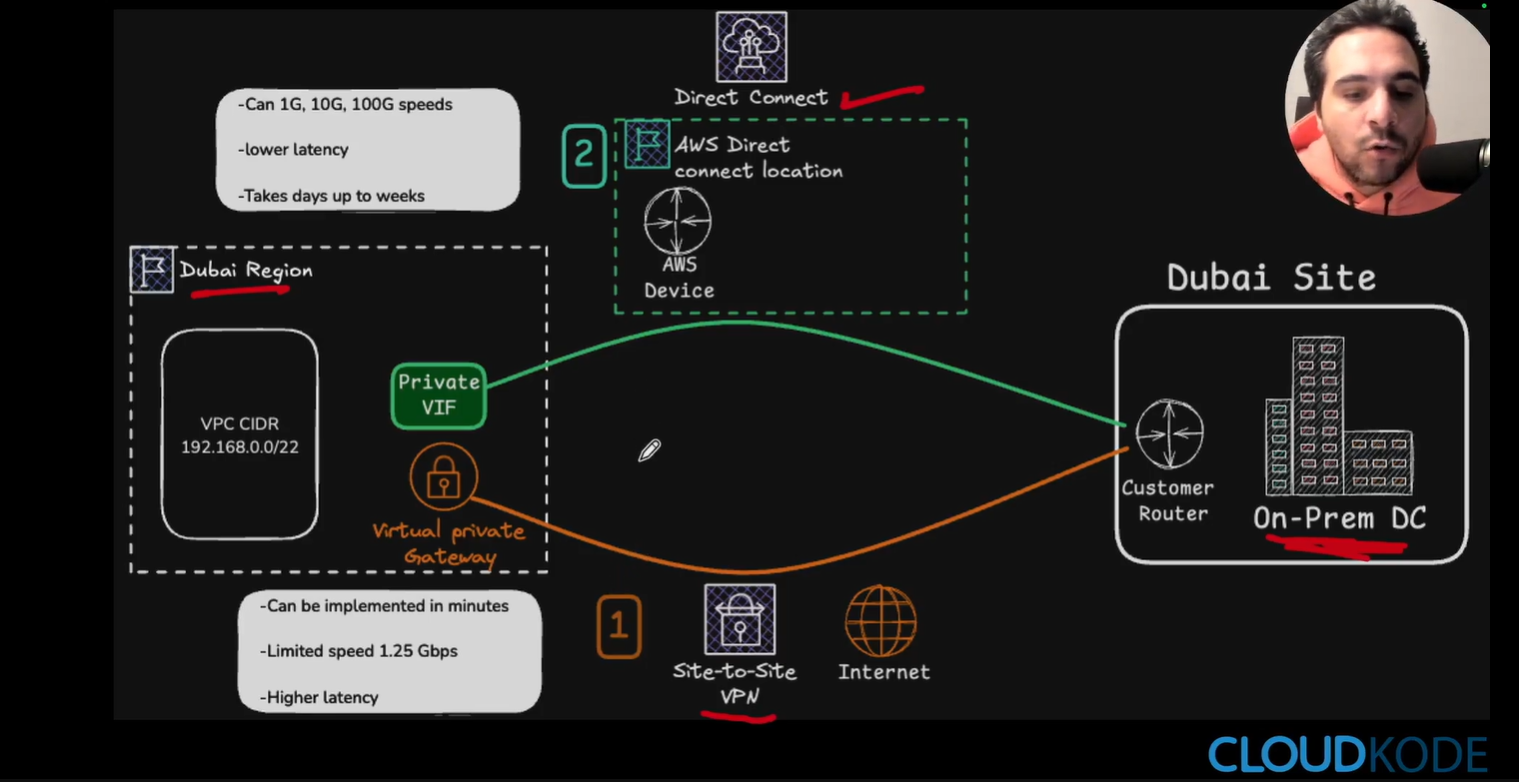


---

## 7.49 Site-to-Site VPN Architecture


![](https://miro.medium.com/v2/resize:fit:1200/1*8CJepMnRPch4VBT2IciUkg.png)

Example:

```text
+---------------------------+
|   Company Data Center     |
|                           |
| 192.168.0.0/16            |
+-------------+-------------+
              |
              |
       Customer Gateway
              |
              |
      ==================
       IPsec VPN Tunnel
      ==================
              |
              |
   Virtual Private Gateway
              |
              |
+-------------v-------------+
|          AWS VPC          |
|                           |
| 10.0.0.0/16               |
|                           |
| EC2          RDS          |
+---------------------------+
```

The connection is encrypted.

However, it uses the:

```text
Public Internet
```

as its underlying transport.

---

## 7.50 AWS Direct Connect

**AWS Direct Connect** provides dedicated network connectivity between your network and AWS.

![](https://ibkrm.github.io/aws-sa-pro-notes/networking-and-hybrid/direct-connect/dx-concepts.png)


Instead of using only:

```text
Company
   |
Public Internet
   |
AWS
```

you can use:

```text
Company
   |
Dedicated Connectivity
   |
AWS Direct Connect
   |
AWS
```

It is commonly used by organizations requiring more predictable connectivity between their own infrastructure and AWS.

---

## 7.51 Direct Connect Architecture

Example:

```text
Corporate Data Center
        |
        |
Customer Router
        |
        |
Dedicated Connectivity
        |
        |
Direct Connect Location
        |
        |
AWS Network
        |
        |
AWS VPC
```

Conceptually:

```text
On-Premises
      |
      |
AWS Direct Connect
      |
      |
AWS Cloud
```


> Two types of direct connect

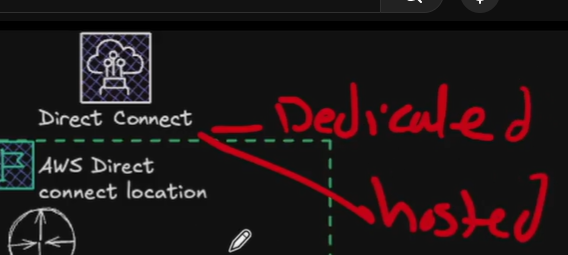

---

## 7.52 VPN vs Direct Connect

The main conceptual difference is:

### Site-to-Site VPN

```text
On-Premises
     |
     |
Public Internet
     |
Encrypted VPN
     |
AWS
```

### Direct Connect

```text
On-Premises
     |
     |
Dedicated Connectivity
     |
AWS
```

---

## 7.53 Site-to-Site VPN Characteristics

VPN is generally:

```text
Internet-based
Encrypted
Relatively quick to configure
Lower initial complexity
Suitable for many hybrid environments
```

Example:

```text
Office
  |
 VPN
  |
AWS
```

---

## 7.54 Direct Connect Characteristics

Direct Connect generally provides:

```text
Dedicated connectivity
More predictable network performance
Private connectivity to AWS
Suitability for high-volume hybrid workloads
Enterprise connectivity options
```

Example:

```text
Corporate Data Center
        |
Direct Connect
        |
AWS
```

---

## 7.55 Site-to-Site VPN vs Direct Connect

| Feature | Site-to-Site VPN | Direct Connect |
|---|---|---|
| Transport | Public Internet | Dedicated connectivity |
| Encryption | IPsec encrypted | Not inherently encrypted by default |
| Setup | Usually faster | More involved |
| Initial complexity | Lower | Higher |
| Performance consistency | Internet-dependent | More predictable |
| Common use | General hybrid connectivity | Enterprise/high-volume connectivity |
| Cost | Generally lower | Generally higher |

---

## 7.56 When to Use Site-to-Site VPN

Use VPN when you need:

```text
Quick hybrid connectivity

Encrypted communication

Lower-cost connectivity

Moderate network traffic

Connection between office/data center and AWS
```

Example:

```text
Small / Medium Company
        |
        |
       VPN
        |
        |
      AWS VPC
```

---

## 7.57 When to Use Direct Connect

Direct Connect may be appropriate when:

```text
Large volumes of data are transferred

More predictable network performance is required

AWS is heavily integrated with the company network

Hybrid cloud is a major part of the architecture

Enterprise connectivity requirements exist
```

Example:

```text
Enterprise Data Center
        |
        |
AWS Direct Connect
        |
        |
AWS
```

---

## 7.58 Direct Connect + VPN

VPN and Direct Connect can also be used together in suitable architectures.

Example:

```text
                  Direct Connect
                +----------------+
                |                |
On-Premises ----+                +---- AWS
                |                |
                +----------------+
                       VPN
```

One purpose may be redundancy.

For example:

```text
Primary connection
=
Direct Connect

Backup connection
=
VPN
```

If one connection fails, network architecture can be designed to use another path.

VPN can also be combined with Direct Connect where encrypted connectivity over Direct Connect is required and the AWS architecture supports it.

---

## 7.59 Hybrid Cloud

A **Hybrid Cloud** environment combines:

```text
On-premises infrastructure
+
Cloud infrastructure
```

Example company environment:

### On-Premises

```text
ERP
Active Directory
Manufacturing Systems
Legacy Applications
Internal Databases
```

### AWS

```text
Web Applications
Analytics
Machine Learning
Data Lake
Backup
Cloud Databases
```

Architecture:

```text
+-----------------------------+
|    Company Data Center      |
|                             |
| ERP                         |
| Active Directory            |
| Manufacturing Systems       |
+-------------+---------------+
              |
              |
       VPN / Direct Connect
              |
              |
+-------------v---------------+
|           AWS VPC           |
|                             |
| EC2                         |
| RDS                         |
| Analytics                   |
| Applications                |
+-----------------------------+
```

This is called:

```text
Hybrid Cloud Architecture
```

---

## 7.60 Example Production VPC Architecture

A more realistic AWS application might use:

```text
                           Internet
                              |
                              |
                     Internet Gateway
                              |
                              |
                    Application Load
                       Balancer
                      /        \
                     /          \
              Public-A        Public-B
                AZ-A            AZ-B
                  |               |
                  |               |
                EC2-A           EC2-B
                  |               |
                  |               |
             Private-A       Private-B
                  \              /
                   \            /
                       RDS
```

The system could also include NAT Gateways:

```text
Private EC2
    |
NAT Gateway
    |
Internet Gateway
    |
Internet
```

And private AWS service access:

```text
Private EC2
     |
VPC Endpoint
     |
S3 / DynamoDB
```

---

## 7.61 Complete VPC Networking Architecture

```text
                              Internet
                                 |
                                 |
                         Internet Gateway
                                 |
                +----------------+----------------+
                |                                 |
         Public Subnet A                   Public Subnet B
                |                                 |
             ALB / EC2                         NAT Gateway
                |                                 |
                +---------------+-----------------+
                                |
                        Private Subnets
                         /            \
                        /              \
                     EC2               RDS
                      |
                      |
                 VPC Endpoint
                      |
                      |
                 AWS Services


On-Premises
     |
     +------ Site-to-Site VPN ------+
     |                              |
     +------ Direct Connect --------+
                                    |
                                  VPC
```

---

## 7.62 Important VPC Components

The major VPC components are:

```text
VPC
│
├── CIDR
│
├── Subnets
│   ├── Public
│   └── Private
│
├── Route Tables
│
├── Internet Gateway
│
├── NAT Gateway
│
├── Security Groups
│
├── Network ACLs
│
├── VPC Endpoints
│
├── VPC Peering
│
├── Transit Gateway
│
├── Flow Logs
│
├── VPN
│
└── Direct Connect
```

---

## 7.63 Security Group vs NACL Quick Review

```text
Security Group

Resource Level
Stateful
Allow rules
```

```text
Network ACL

Subnet Level
Stateless
Allow + Deny rules
```

Exam shortcut:

```text
Stateful firewall
→ Security Group
```

```text
Stateless firewall
→ Network ACL
```

---

## 7.64 Internet Gateway vs NAT Gateway Quick Review

```text
Internet Gateway
        |
        v
Public resources
        |
        v
Internet
```

Used for direct public internet connectivity when resources are properly configured.

While:

```text
Private EC2
    |
NAT Gateway
    |
Internet Gateway
    |
Internet
```

Used when private resources need to initiate outbound internet connections.

---

## 7.65 VPC Peering vs Transit Gateway

### VPC Peering

```text
VPC-A ←→ VPC-B
```

Simple private connection between VPCs.

However:

```text
Non-transitive
```

### Transit Gateway

```text
        VPC-A
          |
VPC-B -- TGW -- VPC-C
          |
        VPC-D
```

Better suited to centrally connecting many networks.

---

## 7.66 VPN vs Direct Connect Exam Shortcut

If the question says:

```text
Encrypted
Fast to deploy
Uses internet
Hybrid connectivity
```

Think:

```text
AWS Site-to-Site VPN
```

If the question says:

```text
Dedicated connection
More predictable performance
Enterprise connectivity
High-volume data transfer
```

Think:

```text
AWS Direct Connect
```

---

## 7.67 VPC Endpoint Exam Shortcut

If the question says:

```text
Access AWS services privately

Do not use the public internet

Do not send traffic through NAT Gateway
```

think:

```text
VPC Endpoint
```

For:

```text
S3
DynamoDB
```

remember:

```text
Gateway Endpoint
```

---

## 7.68 NAT Gateway Exam Shortcut

If the question says:

```text
EC2 is in a private subnet

EC2 needs to download software

EC2 needs internet access

EC2 should not accept direct internet connections
```

think:

```text
NAT Gateway
```

Architecture:

```text
Private EC2
    |
NAT Gateway
    |
Internet Gateway
    |
Internet
```

---

## 7.69 Public vs Private Subnet Exam Shortcut

### Public Subnet

```text
Route:

0.0.0.0/0
      |
      v
Internet Gateway
```

### Private Subnet

No direct route to:

```text
Internet Gateway
```

It may instead use:

```text
0.0.0.0/0
      |
      v
NAT Gateway
```

for outbound internet access.

---

## 7.70 Final VPC Mental Model

Think of VPC networking in the following order:

```text
1. VPC
   ↓
Your private AWS network

2. CIDR
   ↓
Defines available IP addresses

3. Subnets
   ↓
Divide the VPC network

4. Availability Zones
   ↓
Provide physical separation and availability

5. Route Tables
   ↓
Determine where traffic goes

6. Internet Gateway
   ↓
Provides internet connectivity

7. NAT Gateway
   ↓
Provides outbound internet access for private resources

8. Security Groups
   ↓
Stateful resource firewall

9. Network ACL
   ↓
Stateless subnet firewall

10. VPC Endpoint
    ↓
Private access to supported AWS services

11. VPC Peering
    ↓
Connect two VPCs privately

12. Transit Gateway
    ↓
Central hub for many networks

13. VPN
    ↓
Encrypted hybrid connection over the internet

14. Direct Connect
    ↓
Dedicated connectivity between on-premises and AWS
```

---

## 7.71 CLF-C02 Key Points

Remember these for the AWS Cloud Practitioner exam:

```text
VPC
=
Logically isolated AWS network
```

```text
Subnet
=
A portion of a VPC IP range in one Availability Zone
```

```text
Public Subnet
=
Has a route to an Internet Gateway
```

```text
Internet Gateway
=
Connects a VPC with the internet
```

```text
Route Table
=
Determines where network traffic goes
```

```text
Security Group
=
Stateful resource-level firewall
```

```text
Network ACL
=
Stateless subnet-level firewall
```

```text
NAT Gateway
=
Outbound internet connectivity for private subnet resources
```

```text
VPC Endpoint
=
Private connectivity to supported AWS services
```

```text
VPC Peering
=
Private connection between VPCs
```

```text
Transit Gateway
=
Central networking hub
```

```text
Site-to-Site VPN
=
Encrypted AWS/on-premises connectivity over the internet
```

```text
AWS Direct Connect
=
Dedicated connectivity between your network and AWS
```

---

## 7.72 Final Summary

The complete VPC networking model can be represented as:

```text
                         AWS Cloud

                    +------------------+
                    |       VPC        |
                    |   10.0.0.0/16    |
                    +---------+--------+
                              |
              +---------------+---------------+
              |                               |
       Public Subnet                   Private Subnet
       10.0.1.0/24                     10.0.2.0/24
              |                               |
             ALB                             EC2
              |                               |
             EC2                         NAT Gateway
                                              |
                                              |
                                        Internet Gateway
                                              |
                                           Internet
```

For private AWS service connectivity:

```text
Private EC2
     |
VPC Endpoint
     |
S3 / DynamoDB
```

For VPC-to-VPC connectivity:

```text
VPC-A
  |
VPC Peering
  |
VPC-B
```

For many networks:

```text
VPC-A
   |
VPC-B -- Transit Gateway -- VPC-C
   |
VPC-D
```

For hybrid cloud:

```text
On-Premises
     |
     +---- VPN ------------> AWS VPC
     |
     +---- Direct Connect -> AWS
```

The most important distinction to remember is:

```text
VPN
=
Encrypted connection over the internet
```

versus:

```text
Direct Connect
=
Dedicated connectivity to AWS
```